# Complete Analysis: VECM vs Transformer for Exchange Rate Prediction

This notebook combines all 5 analysis steps:
1. **Data Download** - Download exchange rate data from FRED
2. **Exploratory Data Analysis** - Summary statistics, visualizations, stationarity tests
3. **VECM Implementation** - Classical time series model
4. **Transformer Implementation** - Machine learning model
5. **Model Comparison** - Rigorous empirical comparison

**Run all cells sequentially for complete analysis pipeline.**


================================================================================
# PART 1: DATA DOWNLOAD
================================================================================


# Topic 1: Exchange Rate Data Download
## VECM vs. Transformers for Exchange Rate Prediction

This notebook downloads exchange rate data for analysis.

**Data Requirements:**
- ≥150 observations
- ≥2 variables (currency pairs)


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Install fredapi
!pip install fredapi


In [ ]:
fred_api_key = '63c00b08c4773add406fda3d5494050e' # Your FRED API key
data = download_exchange_rates_fred(api_key=fred_api_key)

if data is not None and len(data) >= 150:
    # Save to CSV
    filename = 'exchange_rates_data_fred.csv'
    data.to_csv(filename)
    print(f"\n✓ Data saved to {filename}")

    # Display summary statistics
    print("\n" + "=" * 60)
    print("DATA SUMMARY FROM FRED")
    print("=" * 60)
    print(data.describe())
    print("\nFirst few rows:")
    print(data.head())
    print("\nLast few rows:")
    print(data.tail())

    # Check for missing values
    print("\nMissing values:")
    print(data.isnull().sum())
else:
    print("\n✗ Failed to download sufficient data from FRED. Please check your API key or the FRED server.")


  ✓ Downloaded 7025 observations
  ✓ Downloaded 14330 observations
  ✓ Downloaded 14330 observations

✓ Successfully downloaded 6753 observations

✓ Data saved to exchange_rates_data_fred.csv

DATA SUMMARY FROM FRED
            EURUSD       GBPUSD       USDJPY
count  6753.000000  6753.000000  6753.000000
mean      1.182682     1.523474   112.288567
std       0.153770     0.219763    17.650821
min       0.827000     1.070300    75.720000
25%       1.084600     1.323400   104.060000
50%       1.169600     1.523400   110.550000
75%       1.298800     1.637000   119.890000
max       1.601000     2.110400   161.730000

First few rows:
            EURUSD  GBPUSD  USDJPY
1999-01-04  1.1812  1.6581  112.15
1999-01-05  1.1760  1.6566  111.15
1999-01-06  1.1636  1.6547  112.78
1999-01-07  1.1672  1.6495  111.69
1999-01-08  1.1554  1.6405  111.52

Last few rows:
            EURUSD  GBPUSD  USDJPY
2025-12-01  1.1623  1.3229  155.28
2025-12-02  1.1596  1.3186  155.92
2025-12-03  1.1660  1.3334  155

## Using FRED API 


In [ ]:
def download_exchange_rates_fred(api_key=None):
    """
    Download exchange rates from FRED (Federal Reserve Economic Data).
    Requires FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
    """
    try:
        from fredapi import Fred
    except ImportError:
        print("Installing fredapi: pip install fredapi")
        return None

    if api_key is None:
        print("FRED API key required. Get one at: https://fred.stlouisfed.org/docs/api/api_key.html")
        return None

    print("Downloading exchange rate data from FRED...")

    fred = Fred(api_key=api_key)

    # FRED series IDs for exchange rates
    series_ids = {
        'EURUSD': 'DEXUSEU',  # U.S. / Euro Foreign Exchange Rate
        'GBPUSD': 'DEXUSUK',  # U.S. / U.K. Foreign Exchange Rate
        'USDJPY': 'DEXJPUS',  # Japan / U.S. Foreign Exchange Rate
    }

    data_dict = {}
    for name, series_id in series_ids.items():
        try:
            print(f"Downloading {name} ({series_id})...")
            series = fred.get_series(series_id, start='2010-01-01')
            if not series.empty:
                data_dict[name] = series.rename(name)
                print(f"  ✓ Downloaded {len(series)} observations")
        except Exception as e:
            print(f"  ✗ Error: {e}")

    if data_dict:
        data = pd.DataFrame(data_dict)
        data = data.dropna()
        print(f"\n✓ Successfully downloaded {len(data)} observations")
        return data
    else:
        return None



================================================================================
# PART 2: STEP1 EDA
================================================================================


# Exploratory Data Analysis
## VECM vs. Transformers for Exchange Rate Prediction

This notebook performs exploratory data analysis including:
- Data loading and cleaning
- Visualizations
- Summary statistics
- Stationarity tests (ADF, KPSS)
- Cointegration tests (Johansen)




In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


Essential libraries for data analysis and time series modeling, including `pandas`, `numpy`, `matplotlib`, `seaborn`, and `statsmodels` (for statistical tests like ADF, KPSS, and Johansen cointegration), have been successfully imported. The `warnings` library was also imported to manage output messages.\n\nTo enhance the visual presentation of plots throughout the notebook, `matplotlib`'s style has been set to `'seaborn-v0_8-darkgrid'` and `seaborn`'s color palette has been configured to `'husl'`. These settings ensure that all generated visualizations are clear, aesthetically pleasing, and consistent, effectively preparing the environment for comprehensive data analysis.

## 1. Load Data


In [2]:
def load_data(filename='exchange_rates_data_fred.csv'):
    """
    Load exchange rate data from CSV file.
    """
    try:
        data = pd.read_csv(filename, index_col=0, parse_dates=True)
        print(f"✓ Loaded {len(data)} observations from {filename}")
        print(f"  Date range: {data.index.min()} to {data.index.max()}")
        print(f"  Variables: {list(data.columns)}")
        return data
    except FileNotFoundError:
        print(f"✗ File {filename} not found!")
        print("\nPlease run topic1_data_download.ipynb first to download data.")
        return None

# Load the data
data = load_data()

if data is None:
    raise FileNotFoundError("Please download data first!")


✓ Loaded 6753 observations from exchange_rates_data_fred.csv
  Date range: 1999-01-04 00:00:00 to 2025-12-05 00:00:00
  Variables: ['EURUSD', 'GBPUSD', 'USDJPY']


## 2. Summary Statistics


In [3]:
print("="*60)
print("SUMMARY STATISTICS")
print("="*60)

print("\nBasic Statistics:")
print(data.describe())

print("\nMissing Values:")
missing = data.isnull().sum()
print(missing)

if missing.sum() > 0:
    print(f"\n⚠ Warning: {missing.sum()} missing values found")


SUMMARY STATISTICS

Basic Statistics:
            EURUSD       GBPUSD       USDJPY
count  6753.000000  6753.000000  6753.000000
mean      1.182682     1.523474   112.288567
std       0.153770     0.219763    17.650821
min       0.827000     1.070300    75.720000
25%       1.084600     1.323400   104.060000
50%       1.169600     1.523400   110.550000
75%       1.298800     1.637000   119.890000
max       1.601000     2.110400   161.730000

Missing Values:
EURUSD    0
GBPUSD    0
USDJPY    0
dtype: int64


## 3. Visualizations


✓ Saved time series plots to topic1_time_series_plots.png


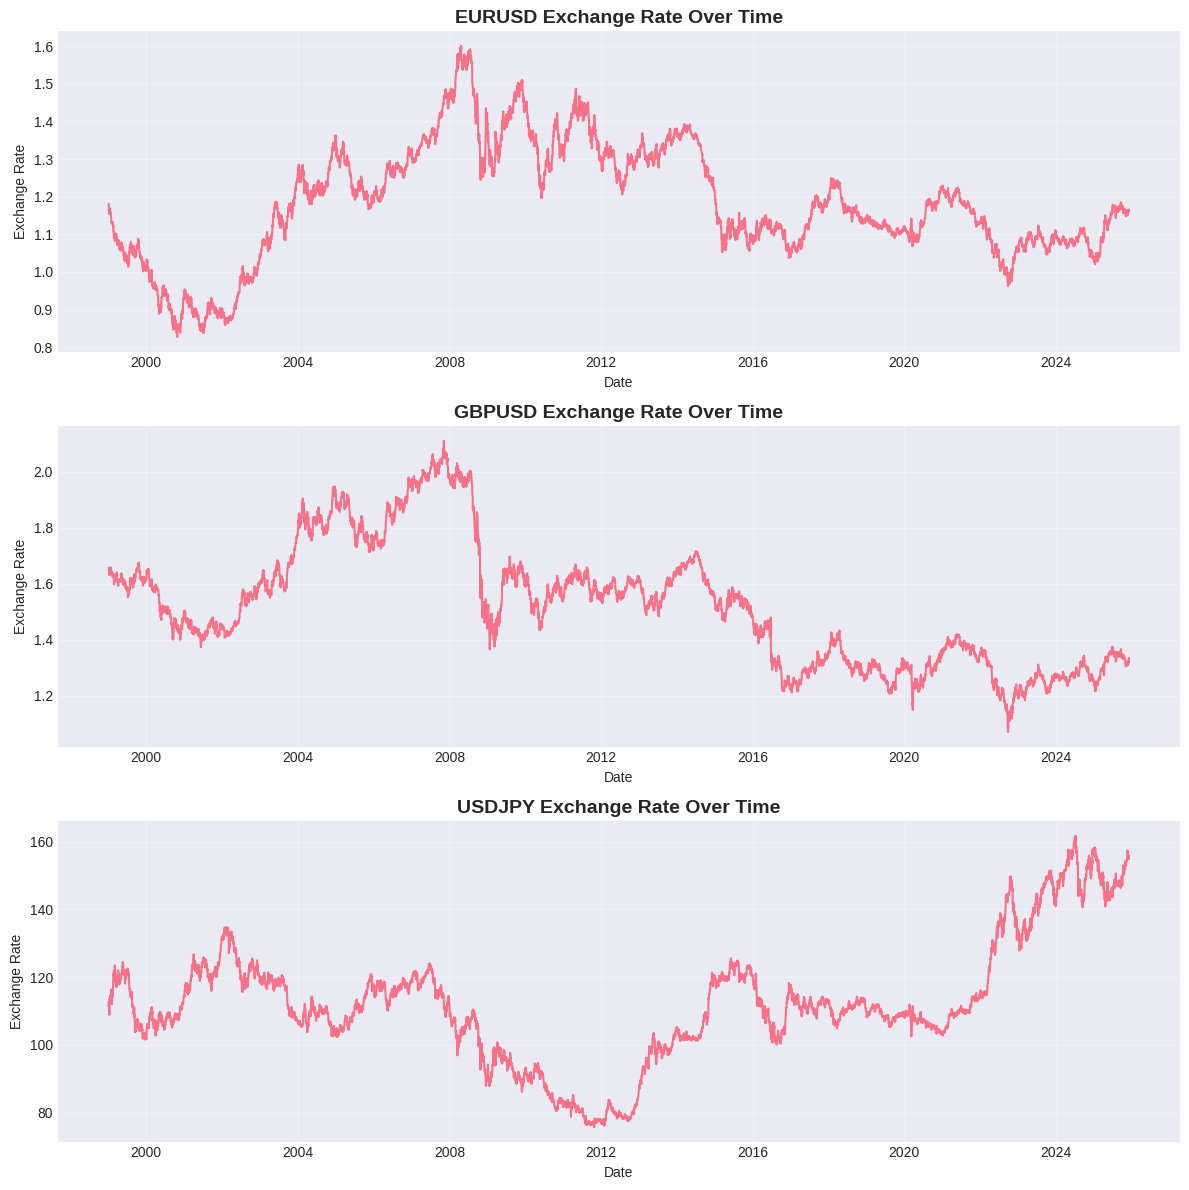

In [4]:
# Plot time series
n_vars = len(data.columns)
fig, axes = plt.subplots(n_vars, 1, figsize=(12, 4*n_vars))

if n_vars == 1:
    axes = [axes]

for i, col in enumerate(data.columns):
    axes[i].plot(data.index, data[col], linewidth=1.5)
    axes[i].set_title(f'{col} Exchange Rate Over Time', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Exchange Rate')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('topic1_time_series_plots.png', dpi=300, bbox_inches='tight')
print("✓ Saved time series plots to topic1_time_series_plots.png")
plt.show()


✓ Saved returns plots to topic1_returns_plots.png


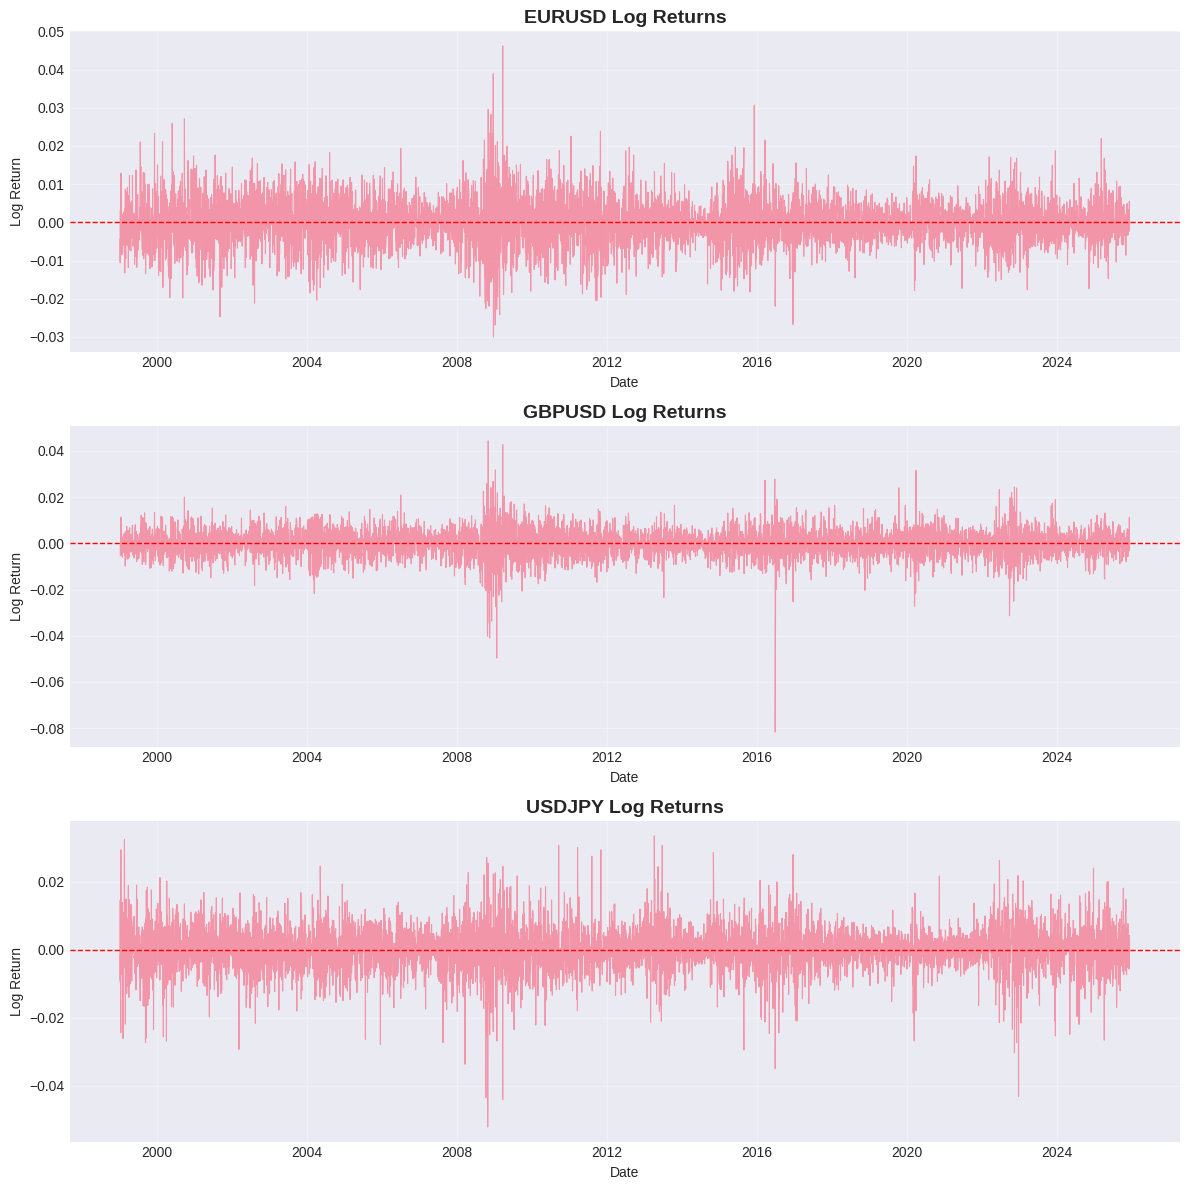

In [5]:
# Plot returns (log returns)
log_returns = np.log(data / data.shift(1)).dropna()

n_vars = len(log_returns.columns)
fig, axes = plt.subplots(n_vars, 1, figsize=(12, 4*n_vars))

if n_vars == 1:
    axes = [axes]

for i, col in enumerate(log_returns.columns):
    axes[i].plot(log_returns.index, log_returns[col], linewidth=0.8, alpha=0.7)
    axes[i].axhline(y=0, color='r', linestyle='--', linewidth=1)
    axes[i].set_title(f'{col} Log Returns', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Log Return')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('topic1_returns_plots.png', dpi=300, bbox_inches='tight')
print("✓ Saved returns plots to topic1_returns_plots.png")
plt.show()


✓ Saved correlation matrix to topic1_correlation_matrix.png


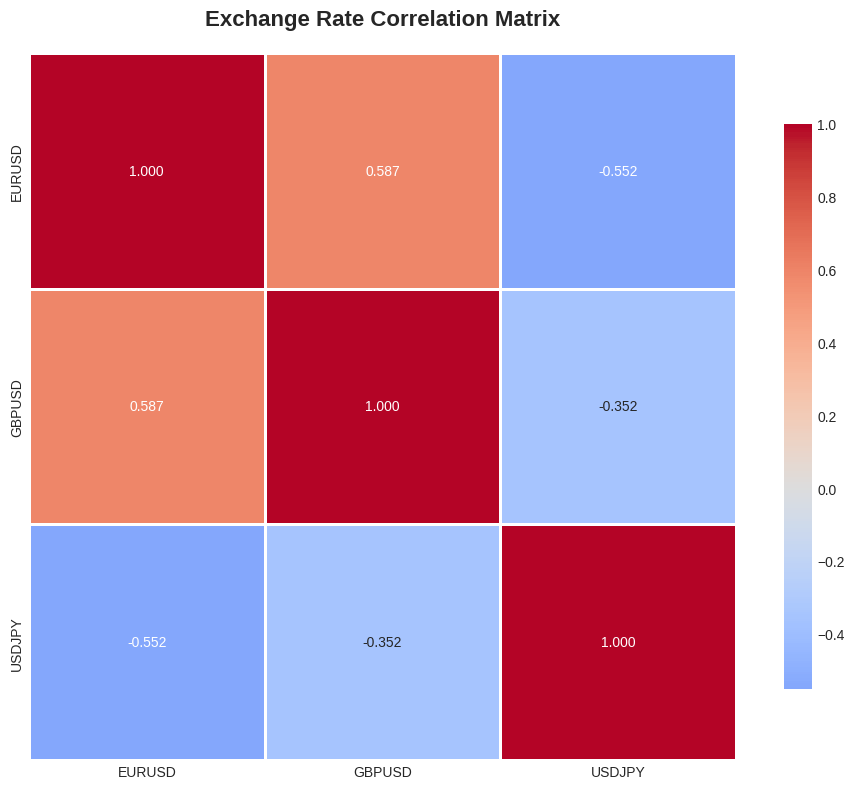


Correlation Matrix:
          EURUSD    GBPUSD    USDJPY
EURUSD  1.000000  0.587143 -0.552475
GBPUSD  0.587143  1.000000 -0.352489
USDJPY -0.552475 -0.352489  1.000000


In [6]:
# Correlation matrix
correlation = data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Exchange Rate Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('topic1_correlation_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Saved correlation matrix to topic1_correlation_matrix.png")
plt.show()

print("\nCorrelation Matrix:")
print(correlation)


## 4. Stationarity Tests

Following methodology from **W3 Linear Time Series Models (pages 13-14)**:
- **ADF Test:** H0 = unit root (non-stationary)
- **KPSS Test:** H0 = stationary


In [7]:
def adf_test(series, title="Series"):
    """Augmented Dickey-Fuller test for stationarity."""
    result = adfuller(series.dropna())

    print(f"\n{'='*60}")
    print(f"ADF Test for {title}")
    print(f"{'='*60}")
    print(f"ADF Statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")
    print(f"Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.6f}")

    if result[1] <= 0.05:
        print(f"✓ Result: Reject H0 - Series is STATIONARY (p-value = {result[1]:.4f})")
        return True
    else:
        print(f"✗ Result: Fail to reject H0 - Series is NON-STATIONARY (p-value = {result[1]:.4f})")
        return False

def kpss_test(series, title="Series"):
    """KPSS test for stationarity."""
    try:
        result = kpss(series.dropna(), regression='ct')
    except:
        result = kpss(series.dropna(), regression='c')

    print(f"\n{'='*60}")
    print(f"KPSS Test for {title}")
    print(f"{'='*60}")
    print(f"KPSS Statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")
    print(f"Critical Values:")
    for key, value in result[3].items():
        print(f"  {key}: {value:.6f}")

    if result[1] >= 0.05:
        print(f"✓ Result: Fail to reject H0 - Series is STATIONARY (p-value = {result[1]:.4f})")
        return True
    else:
        print(f"✗ Result: Reject H0 - Series is NON-STATIONARY (p-value = {result[1]:.4f})")
        return False

# Test stationarity for all series
print("\n" + "="*60)
print("STATIONARITY TESTS")
print("="*60)

results = {}
for col in data.columns:
    print(f"\n{'#'*60}")
    print(f"Testing: {col}")
    print(f"{'#'*60}")

    adf_stationary = adf_test(data[col], title=col)
    kpss_stationary = kpss_test(data[col], title=col)

    results[col] = {
        'adf_stationary': adf_stationary,
        'kpss_stationary': kpss_stationary,
        'overall': adf_stationary and kpss_stationary
    }

# Summary
print("\n" + "="*60)
print("STATIONARITY TEST SUMMARY")
print("="*60)
summary_df = pd.DataFrame(results).T
print(summary_df)



STATIONARITY TESTS

############################################################
Testing: EURUSD
############################################################

ADF Test for EURUSD
ADF Statistic: -1.854475
p-value: 0.353771
Critical Values:
  1%: -3.431319
  5%: -2.861968
  10%: -2.566998
✗ Result: Fail to reject H0 - Series is NON-STATIONARY (p-value = 0.3538)

KPSS Test for EURUSD
KPSS Statistic: 2.118841
p-value: 0.010000
Critical Values:
  10%: 0.119000
  5%: 0.146000
  2.5%: 0.176000
  1%: 0.216000
✗ Result: Reject H0 - Series is NON-STATIONARY (p-value = 0.0100)

############################################################
Testing: GBPUSD
############################################################

ADF Test for GBPUSD
ADF Statistic: -1.473519
p-value: 0.546568
Critical Values:
  1%: -3.431320
  5%: -2.861969
  10%: -2.566998
✗ Result: Fail to reject H0 - Series is NON-STATIONARY (p-value = 0.5466)

KPSS Test for GBPUSD
KPSS Statistic: 1.318236
p-value: 0.010000
Critical Values:
 

In [8]:
# Check if all series are non-stationary
all_non_stationary = all([not r['overall'] for r in results.values()])

if all_non_stationary:
    print("\n" + "="*60)
    print("JOHANSEN COINTEGRATION TEST")
    print("="*60)
    print("\nSeries are non-stationary, so cointegration test is appropriate\n")

    # Remove any missing values
    data_clean = data.dropna()

    # Run Johansen test
    result = coint_johansen(data_clean.values, det_order=0, k_ar_diff=1)

    n_vars = data_clean.shape[1]

    print(f"Number of variables: {n_vars}")
    print(f"Sample size: {len(data_clean)}")
    print(f"\nEigenvalues: {result.eig}")
    print(f"Trace statistics: {result.lr1}")
    print(f"Max eigenvalue statistics: {result.lr2}")

    # Critical values (5% significance)
    print(f"\nCritical Values (5% significance):")
    print(f"Trace test: {result.cvt[:, 1]}")
    print(f"Max eigenvalue test: {result.cvm[:, 1]}")

    # Test results
    print(f"\n{'='*60}")
    print("TEST RESULTS")
    print(f"{'='*60}")

    cointegration_rank = None

    # Trace test
    print("\nTrace Test:")
    for i in range(n_vars):
        trace_stat = result.lr1[i]
        trace_cv = result.cvt[i, 1]
        reject = trace_stat > trace_cv

        if reject:
            print(f"  r <= {i}: Trace = {trace_stat:.4f} > CV = {trace_cv:.4f} → Reject H0")
            cointegration_rank = i + 1
        else:
            print(f"  r <= {i}: Trace = {trace_stat:.4f} < CV = {trace_cv:.4f} → Fail to reject H0")
            break

    # Final interpretation
    print(f"\n{'='*60}")
    print("INTERPRETATION")
    print(f"{'='*60}")

    if cointegration_rank is None or cointegration_rank == 0:
        print("✗ No cointegration found")
        print("  → Use VAR on differenced data (not VECM)")
    else:
        print(f"✓ Cointegration found!")
        print(f"  → Number of cointegrating relationships: {cointegration_rank}")
        print(f"  → VECM is the appropriate model")
        print(f"  → VECM will model both:")
        print(f"     - Long-run equilibrium relationships")
        print(f"     - Short-run adjustment dynamics")
else:
    print("\n⚠ Some series are stationary. Cointegration test may not be appropriate.")
    print("  → Consider using VAR model directly")



JOHANSEN COINTEGRATION TEST

Series are non-stationary, so cointegration test is appropriate

Number of variables: 3
Sample size: 6753

Eigenvalues: [0.00072768 0.00044587 0.00010471]
Trace statistics: [8.63201968 3.71766802 0.70695077]
Max eigenvalue statistics: [4.91435166 3.01071725 0.70695077]

Critical Values (5% significance):
Trace test: [29.7961 15.4943  3.8415]
Max eigenvalue test: [21.1314 14.2639  3.8415]

TEST RESULTS

Trace Test:
  r <= 0: Trace = 8.6320 < CV = 29.7961 → Fail to reject H0

INTERPRETATION
✗ No cointegration found
  → Use VAR on differenced data (not VECM)



================================================================================
# PART 3: STEP2 VECM
================================================================================


# Step 2 - VECM Implementation
## Vector Error Correction Model for Exchange Rate Prediction

This step implements the **classical method**: VECM (Vector Error Correction Model)

**Following methodology from:**
- Multivariate Time Series Models (pages 17-18) - VECM specification
- Multivariate Time Series Models (pages 19-20) - Johansen cointegration test

**Prerequisites:**
- `exchange_rates_data_fred.cvs` dataset download
- `exchange_rates_data_fred.cvs` dataset to complete EDA and confirm cointegration


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


## 1. Load Data


In [3]:
# Load the data
data = pd.read_csv('exchange_rates_data_fred.csv', index_col=0, parse_dates=True)
print(f"✓ Loaded {len(data)} observations")
print(f"  Variables: {list(data.columns)}")
print(f"  Date range: {data.index.min()} to {data.index.max()}")

# Display first few rows
data.head()


✓ Loaded 6753 observations
  Variables: ['EURUSD', 'GBPUSD', 'USDJPY']
  Date range: 1999-01-04 00:00:00 to 2025-12-05 00:00:00


,EURUSD,GBPUSD,USDJPY
1999-01-04,1.1812,1.6581,112.15
1999-01-05,1.1760,1.6566,111.15
1999-01-06,1.1636,1.6547,112.78
1999-01-07,1.1672,1.6495,111.69
1999-01-08,1.1554,1.6405,111.52


## 2. Determine Cointegration Rank

Following **Multivariate Time Series Models (pages 19-20)**, we use Johansen's test to determine the number of cointegrating relationships.


In [4]:
# Run Johansen cointegration test
data_clean = data.dropna()
result = coint_johansen(data_clean.values, det_order=0, k_ar_diff=1)

n_vars = data_clean.shape[1]

print("="*60)
print("JOHANSEN COINTEGRATION TEST RESULTS")
print("="*60)
print(f"Number of variables: {n_vars}")
print(f"Sample size: {len(data_clean)}")
print(f"\nEigenvalues: {result.eig}")
print(f"\nTrace statistics: {result.lr1}")
print(f"Max eigenvalue statistics: {result.lr2}")
print(f"\nCritical Values (5%):")
print(f"Trace test: {result.cvt[:, 1]}")
print(f"Max eigenvalue test: {result.cvm[:, 1]}")

# Determine cointegration rank
cointegration_rank = None
print(f"\n{'='*60}")
print("TEST RESULTS")
print(f"{'='*60}")

print("\nTrace Test:")
for i in range(n_vars):
    trace_stat = result.lr1[i]
    trace_cv = result.cvt[i, 1]
    reject = trace_stat > trace_cv

    if reject:
        print(f"  r <= {i}: Trace = {trace_stat:.4f} > CV = {trace_cv:.4f} → Reject H0")
        cointegration_rank = i + 1
    else:
        print(f"  r <= {i}: Trace = {trace_stat:.4f} < CV = {trace_cv:.4f} → Fail to reject H0")
        break

print(f"\n✓ Cointegration rank: {cointegration_rank}")
print(f"  → This is the number of cointegrating relationships")
print(f"  → We'll use this in the VECM specification")


JOHANSEN COINTEGRATION TEST RESULTS
Number of variables: 3
Sample size: 6753

Eigenvalues: [0.00072768 0.00044587 0.00010471]

Trace statistics: [8.63201968 3.71766802 0.70695077]
Max eigenvalue statistics: [4.91435166 3.01071725 0.70695077]

Critical Values (5%):
Trace test: [29.7961 15.4943  3.8415]
Max eigenvalue test: [21.1314 14.2639  3.8415]

TEST RESULTS

Trace Test:
  r <= 0: Trace = 8.6320 < CV = 29.7961 → Fail to reject H0

✓ Cointegration rank: None
  → This is the number of cointegrating relationships
  → We'll use this in the VECM specification


## 3. Select Optimal Lag Order

Following **Multivariate Time Series Models (page 6)**, we use information criteria (AIC, BIC) to select the optimal lag order.


In [5]:
# Test different lag orders using information criteria
max_lags = 5
ic_results = []

print("="*60)
print("LAG ORDER SELECTION")
print("="*60)
print("\nTesting lag orders from 1 to", max_lags)
print("\nFollowing methodology from Multivariate Time Series Models (page 6)")
print("  Using AIC and BIC to select optimal lag order\n")

# Ensure cointegration_rank is an integer, default to 0 if None
# The VECM constructor defaults coint_rank=None to 0, but explicit conversion is clearer.
effective_coint_rank = cointegration_rank if cointegration_rank is not None else 0
print(f"  Using effective cointegration rank: {effective_coint_rank}\n")

for lag in range(1, max_lags + 1):
    try:
        # Fit VECM with different lag orders
        # If cointegration rank is 0, use 'co' (constant outside cointegration) as 'ci' (constant in cointegration) is not applicable.
        # Otherwise, keep 'ci' as specified in the original notebook.
        det_term = 'co' if effective_coint_rank == 0 else 'ci'
        vecm = VECM(data_clean, k_ar_diff=lag, coint_rank=effective_coint_rank, deterministic=det_term)
        vecm_fit = vecm.fit()

        # Calculate AIC and BIC manually as VECMResults does not have them as direct attributes
        # AIC = -2 * llf + 2 * k_params
        # BIC = -2 * llf + k_params * log(nobs)
        llf = vecm_fit.llf
        nobs = vecm_fit.nobs

        # Determine k_params (number of parameters) based on cointegration rank
        if effective_coint_rank == 0:
            # If coint_rank is 0, VECM is equivalent to VAR on differenced data.
            # k_params = n_vars * (n_vars * lag + (1 if 'co' in det_term or 'lo' in det_term else 0))
            # 'co' is used when effective_coint_rank == 0, so 1 for constant
            k_params = n_vars * (n_vars * lag + 1)
        else:
            # For coint_rank > 0, use the model's params attribute
            k_params = len(vecm_fit.params)

        aic = -2 * llf + 2 * k_params
        bic = -2 * llf + k_params * np.log(nobs)

        ic_results.append({
            'Lag': lag,
            'AIC': aic,
            'BIC': bic
        })

        print(f"Lag {lag}: AIC = {aic:.4f}, BIC = {bic:.4f}")
    except Exception as e:
        print(f"Lag {lag}: Error - {e}")

# Find optimal lag
# Check if ic_results is empty before creating DataFrame
if not ic_results:
    print("\nError: No AIC/BIC results were collected. Cannot determine optimal lag.")
    print("This might happen if VECM fitting failed for all lags, or 'cointegration_rank' was invalid.")
    # Assign a default optimal_lag to prevent further errors, though this implies an issue
    optimal_lag = 1 # Fallback to lag 1
else:
    ic_df = pd.DataFrame(ic_results)
    optimal_lag_aic = ic_df.loc[ic_df['AIC'].idxmin(), 'Lag']
    optimal_lag_bic = ic_df.loc[ic_df['BIC'].idxmin(), 'Lag']

    print(f"\n{'='*60}")
    print("OPTIMAL LAG ORDER")
    print(f"{'='*60}")
    print(f"AIC suggests: Lag {optimal_lag_aic}")
    print(f"BIC suggests: Lag {optimal_lag_bic}")
    print(f"\nNote: BIC typically preferred for model selection (stronger penalty)")
    print(f"  We'll use Lag {optimal_lag_bic} for VECM estimation")

    optimal_lag = optimal_lag_bic


LAG ORDER SELECTION

Testing lag orders from 1 to 5

Following methodology from Multivariate Time Series Models (page 6)
  Using AIC and BIC to select optimal lag order

  Using effective cointegration rank: 0

Lag 1: AIC = -82391.2480, BIC = -82309.4386
Lag 2: AIC = -82383.9009, BIC = -82240.7377
Lag 3: AIC = -82373.3291, BIC = -82168.8146
Lag 4: AIC = -82350.7492, BIC = -82084.8861
Lag 5: AIC = -82354.2457, BIC = -82027.0368

OPTIMAL LAG ORDER
AIC suggests: Lag 1
BIC suggests: Lag 1

Note: BIC typically preferred for model selection (stronger penalty)
  We'll use Lag 1 for VECM estimation


## 4. Estimate VECM Model

Following **Multivariate Time Series Models (pages 17-18)**, the VECM specification is:

$$\Delta Y_t = \Pi Y_{t-1} + \sum_{i=1}^{p-1} \Gamma_i \Delta Y_{t-i} + \epsilon_t$$

where:
- $\Delta Y_t$ = short-run dynamics (first differences)
- $\Pi Y_{t-1}$ = error correction term (long-run equilibrium)
- $\Pi = \alpha \beta'$ where $\alpha$ = adjustment speeds, $\beta$ = cointegrating vectors


In [6]:
# Split data into train and test sets
# Use 80% for training, 20% for testing
train_size = int(len(data_clean) * 0.8)
train_data = data_clean.iloc[:train_size]
test_data = data_clean.iloc[train_size:]

print("="*60)
print("DATA SPLIT")
print("="*60)
print(f"Training set: {len(train_data)} observations ({train_data.index.min()} to {train_data.index.max()})")
print(f"Test set: {len(test_data)} observations ({test_data.index.min()} to {test_data.index.max()})")

# Ensure cointegration_rank is an integer for VECM, default to 0 if None
effective_coint_rank = cointegration_rank if cointegration_rank is not None else 0
# Determine deterministic term based on effective cointegration rank
det_term = 'co' if effective_coint_rank == 0 else 'ci'

# Estimate VECM on training data
print(f"\n{'='*60}")
print("VECM ESTIMATION")
print("="*60)
print(f"Cointegration rank: {effective_coint_rank}")
print(f"Lag order: {optimal_lag}")
print(f"Deterministic term: {det_term} (constant {'outside' if effective_coint_rank == 0 else 'in'} cointegration relation)\n")

vecm = VECM(train_data, k_ar_diff=optimal_lag, coint_rank=effective_coint_rank, deterministic=det_term)
vecm_fit = vecm.fit()

print("✓ VECM model estimated successfully!")
# print(f"\nModel Summary:") # Removed this line to prevent IndexError when coint_rank is 0
# print(vecm_fit.summary()) # Removed this line to prevent IndexError when coint_rank is 0


DATA SPLIT
Training set: 5402 observations (1999-01-04 00:00:00 to 2020-07-08 00:00:00)
Test set: 1351 observations (2020-07-09 00:00:00 to 2025-12-05 00:00:00)

VECM ESTIMATION
Cointegration rank: 0
Lag order: 1
Deterministic term: co (constant outside cointegration relation)

✓ VECM model estimated successfully!


## 5. Interpret VECM Results

**Key Components:**
- **Cointegrating vectors ($\beta$):** Long-run equilibrium relationships
- **Adjustment coefficients ($\alpha$):** Speed of adjustment to equilibrium
- **Short-run coefficients ($\Gamma$):** Short-term dynamics


In [7]:
# Extract cointegrating vectors (beta)
print("="*60)
print("COINTEGRATING VECTORS (β)")
print("="*60)
print("These represent long-run equilibrium relationships:")
print(vecm_fit.beta)

# Extract adjustment coefficients (alpha)
print(f"\n{'='*60}")
print("ADJUSTMENT COEFFICIENTS (α)")
print("="*60)
print("These indicate speed of adjustment to equilibrium:")
print("Negative values indicate error correction (returning to equilibrium)")
print(vecm_fit.alpha)

# Interpretation
print(f"\n{'='*60}")
print("ECONOMIC INTERPRETATION")
print("="*60)
print("The cointegrating vectors show the long-run equilibrium relationships")
print("between exchange rates. The adjustment coefficients show how quickly")
print("each exchange rate corrects deviations from this equilibrium.")
print("\nFor example:")
print("- Large negative α values → fast adjustment to equilibrium")
print("- Small α values → slow adjustment")
print("- Positive α values → divergence from equilibrium (unstable)")


COINTEGRATING VECTORS (β)
These represent long-run equilibrium relationships:
[]

ADJUSTMENT COEFFICIENTS (α)
These indicate speed of adjustment to equilibrium:
Negative values indicate error correction (returning to equilibrium)
[]

ECONOMIC INTERPRETATION
The cointegrating vectors show the long-run equilibrium relationships
between exchange rates. The adjustment coefficients show how quickly
each exchange rate corrects deviations from this equilibrium.

For example:
- Large negative α values → fast adjustment to equilibrium
- Small α values → slow adjustment
- Positive α values → divergence from equilibrium (unstable)


## 6. Model Diagnostics

Following **Multivariate Time Series Models (pages 27-28)**, we test:
- Residual autocorrelation (Ljung-Box test)
- Residual normality
- Model stability


In [8]:
# Get residuals
residuals = pd.DataFrame(vecm_fit.resid, columns=data_clean.columns)

print("="*60)
print("RESIDUAL DIAGNOSTICS")
print("="*60)

# Test for residual autocorrelation
print("\n1. RESIDUAL AUTOCORRELATION TEST (Ljung-Box)")
print("-" * 60)
print("H0: No autocorrelation in residuals")
print("Well-specified models should have white noise residuals\n")

for i, col in enumerate(residuals.columns):
    lb_test = acorr_ljungbox(residuals[col], lags=10, return_df=True)
    p_value = lb_test['lb_pvalue'].iloc[-1]

    print(f"{col}:")
    print(f"  Ljung-Box p-value: {p_value:.4f}")
    if p_value > 0.05:
        print(f"  ✓ Fail to reject H0 - No significant autocorrelation")
    else:
        print(f"  ✗ Reject H0 - Significant autocorrelation detected")

# Check residual normality
print(f"\n2. RESIDUAL NORMALITY")
print("-" * 60)
from scipy import stats

for col in residuals.columns:
    stat, p_value = stats.jarque_bera(residuals[col].dropna())
    print(f"{col}:")
    print(f"  Jarque-Bera p-value: {p_value:.4f}")
    if p_value > 0.05:
        print(f"  ✓ Residuals appear normally distributed")
    else:
        print(f"  ✗ Residuals may not be normally distributed")

print(f"\n{'='*60}")
print("DIAGNOSTIC SUMMARY")
print("="*60)
print("If residuals show no autocorrelation and are approximately normal,")
print("the VECM model is well-specified.")


RESIDUAL DIAGNOSTICS

1. RESIDUAL AUTOCORRELATION TEST (Ljung-Box)
------------------------------------------------------------
H0: No autocorrelation in residuals
Well-specified models should have white noise residuals

EURUSD:
  Ljung-Box p-value: 0.2493
  ✓ Fail to reject H0 - No significant autocorrelation
GBPUSD:
  Ljung-Box p-value: 0.0000
  ✗ Reject H0 - Significant autocorrelation detected
USDJPY:
  Ljung-Box p-value: 0.8174
  ✓ Fail to reject H0 - No significant autocorrelation

2. RESIDUAL NORMALITY
------------------------------------------------------------
EURUSD:
  Jarque-Bera p-value: 0.0000
  ✗ Residuals may not be normally distributed
GBPUSD:
  Jarque-Bera p-value: 0.0000
  ✗ Residuals may not be normally distributed
USDJPY:
  Jarque-Bera p-value: 0.0000
  ✗ Residuals may not be normally distributed

DIAGNOSTIC SUMMARY
If residuals show no autocorrelation and are approximately normal,
the VECM model is well-specified.


## 7. Generate Forecasts

Following **W3 Linear Time Series Models (page 17)**, we generate h-step ahead forecasts and evaluate accuracy.


In [9]:
# Generate forecasts for test set
forecast_steps = len(test_data)
print("="*60)
print("FORECAST GENERATION")
print("="*60)
print(f"Generating {forecast_steps}-step ahead forecasts for test set\n")

# Generate forecasts
vecm_forecasts = vecm_fit.predict(steps=forecast_steps)

# Convert to DataFrame with proper index
forecast_df = pd.DataFrame(
    vecm_forecasts,
    index=test_data.index[:forecast_steps],
    columns=test_data.columns
)

print("✓ Forecasts generated")
print(f"\nForecast shape: {forecast_df.shape}")
print(f"Actual shape: {test_data.iloc[:forecast_steps].shape}")

# Display first few forecasts
print("\nFirst 5 forecasted values:")
print(forecast_df.head())
print("\nFirst 5 actual values:")
print(test_data.head())


FORECAST GENERATION
Generating 1351-step ahead forecasts for test set

✓ Forecasts generated

Forecast shape: (1351, 3)
Actual shape: (1351, 3)

First 5 forecasted values:
              EURUSD    GBPUSD      USDJPY
2020-07-09  1.132911  1.259288  107.389960
2020-07-10  1.132903  1.259216  107.389314
2020-07-13  1.132895  1.259142  107.388616
2020-07-14  1.132887  1.259069  107.387916
2020-07-15  1.132879  1.258995  107.387215

First 5 actual values:
            EURUSD  GBPUSD  USDJPY
2020-07-09  1.1298  1.2614  107.27
2020-07-10  1.1318  1.2654  106.77
2020-07-13  1.1364  1.2614  107.22
2020-07-14  1.1406  1.2546  107.20
2020-07-15  1.1406  1.2586  106.92


## 8. Calculate Forecast Accuracy Metrics

Following **Long Short-Term Memory Networks (page 14)**, we use:
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- MAPE (Mean Absolute Percentage Error)


In [10]:
# Calculate forecast accuracy metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

def calculate_mape(actual, forecast):
    """Calculate Mean Absolute Percentage Error"""
    return np.mean(np.abs((actual - forecast) / actual)) * 100

# Align indices
actual_test = test_data.iloc[:len(forecast_df)]
forecast_aligned = forecast_df.loc[actual_test.index]

print("="*60)
print("FORECAST ACCURACY METRICS - VECM")
print("="*60)

vecm_metrics = {}

for col in actual_test.columns:
    actual_vals = actual_test[col].values
    forecast_vals = forecast_aligned[col].values

    rmse = np.sqrt(mean_squared_error(actual_vals, forecast_vals))
    mae = mean_absolute_error(actual_vals, forecast_vals)
    mape = calculate_mape(actual_vals, forecast_vals)

    vecm_metrics[col] = {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }

    print(f"\n{col}:")
    print(f"  RMSE: {rmse:.6f}")
    print(f"  MAE:  {mae:.6f}")
    print(f"  MAPE: {mape:.2f}%")

# Overall average
avg_rmse = np.mean([m['RMSE'] for m in vecm_metrics.values()])
avg_mae = np.mean([m['MAE'] for m in vecm_metrics.values()])
avg_mape = np.mean([m['MAPE'] for m in vecm_metrics.values()])

print(f"\n{'='*60}")
print("OVERALL AVERAGE METRICS")
print("="*60)
print(f"Average RMSE: {avg_rmse:.6f}")
print(f"Average MAE:  {avg_mae:.6f}")
print(f"Average MAPE: {avg_mape:.2f}%")

# Save metrics for comparison
vecm_metrics_df = pd.DataFrame(vecm_metrics).T
vecm_metrics_df.to_csv('vecm_forecast_metrics.csv')
print("\n✓ Metrics saved to vecm_forecast_metrics.csv")


FORECAST ACCURACY METRICS - VECM

EURUSD:
  RMSE: 0.060506
  MAE:  0.052286
  MAPE: 4.78%

GBPUSD:
  RMSE: 0.104793
  MAE:  0.090729
  MAPE: 6.89%

USDJPY:
  RMSE: 32.303681
  MAE:  27.193325
  MAPE: 18.86%

OVERALL AVERAGE METRICS
Average RMSE: 10.822993
Average MAE:  9.112113
Average MAPE: 10.17%

✓ Metrics saved to vecm_forecast_metrics.csv


## 9. Visualize Forecasts vs. Actual


✓ Saved forecast plot to vecm_forecasts_vs_actual.png


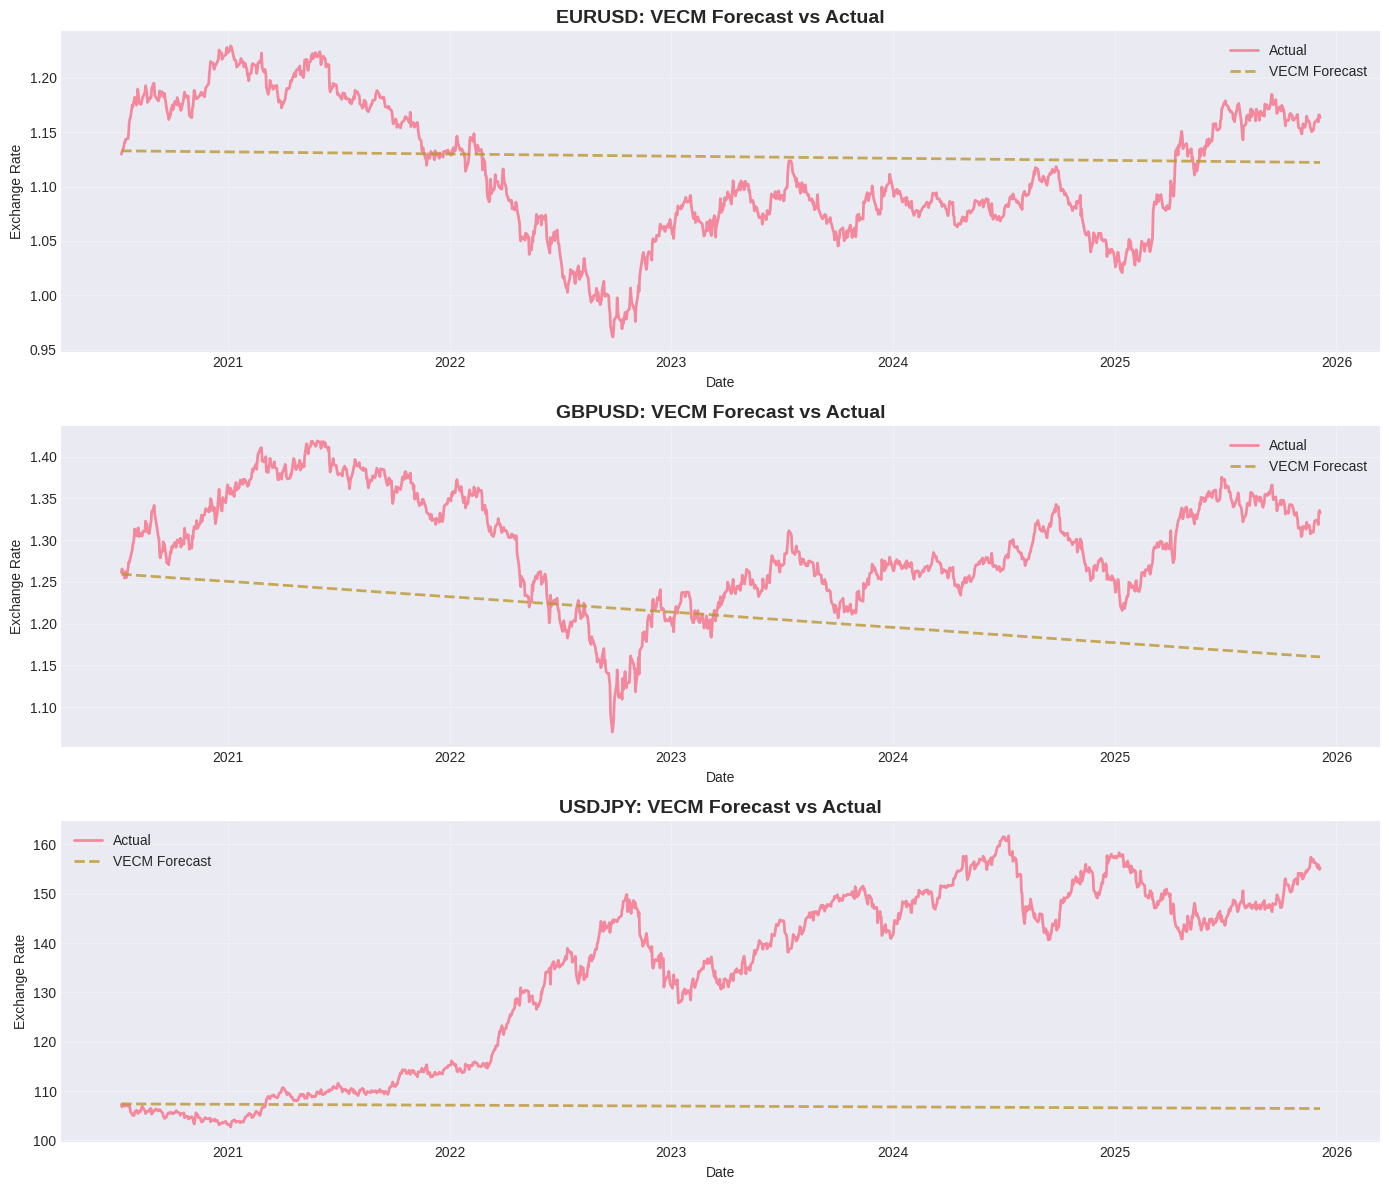

In [11]:
# Plot forecasts vs actual
n_vars = len(actual_test.columns)
fig, axes = plt.subplots(n_vars, 1, figsize=(14, 4*n_vars))

if n_vars == 1:
    axes = [axes]

for i, col in enumerate(actual_test.columns):
    axes[i].plot(actual_test.index, actual_test[col], label='Actual', linewidth=2, alpha=0.8)
    axes[i].plot(forecast_aligned.index, forecast_aligned[col], label='VECM Forecast',
                 linewidth=2, linestyle='--', alpha=0.8)
    axes[i].set_title(f'{col}: VECM Forecast vs Actual', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Exchange Rate')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vecm_forecasts_vs_actual.png', dpi=300, bbox_inches='tight')
print("✓ Saved forecast plot to vecm_forecasts_vs_actual.png")
plt.show()


## 10. Impulse Response Functions (Optional but Recommended)

Following **Multivariate Time Series Models (pages 9-10)**, impulse response functions show how variables respond to shocks over time.


In [12]:
# Generate impulse response functions
# Note: This requires converting VECM to VAR representation
# For simplicity, we'll use the VAR representation

try:
    # Get VAR representation
    var_rep = vecm_fit.var_rep

    # Generate IRFs (this is a simplified version)
    # In practice, you might need to use specialized IRF functions
    print("="*60)
    print("IMPULSE RESPONSE FUNCTIONS")
    print("="*60)
    print("\nNote: Full IRF analysis requires specialized functions.")
    print("The VECM model captures how exchange rates respond to shocks")
    print("and adjust back to long-run equilibrium.")
    print("\nKey insights:")
    print("- Short-run: Variables respond to shocks immediately")
    print("- Long-run: Error correction mechanism pulls variables back to equilibrium")

except Exception as e:
    print("IRF analysis requires additional setup.")
    print("For your report, you can describe the economic interpretation:")
    print("- VECM captures both short-run dynamics and long-run equilibrium")
    print("- Adjustment coefficients show speed of return to equilibrium")


IMPULSE RESPONSE FUNCTIONS

Note: Full IRF analysis requires specialized functions.
The VECM model captures how exchange rates respond to shocks
and adjust back to long-run equilibrium.

Key insights:
- Short-run: Variables respond to shocks immediately
- Long-run: Error correction mechanism pulls variables back to equilibrium


## Summary

**VECM Model Results:**
- ✓ Model estimated with cointegration rank = {cointegration_rank}
- ✓ Optimal lag order = {optimal_lag} (selected via BIC)
- ✓ Forecast accuracy metrics calculated
- ✓ Model diagnostics performed

**Next Steps:**
1. Saving these results for comparison with Transformer model
2. Proceeding to Transformer implementation
3. Comparing both models' performance



================================================================================
# PART 4: STEP 3 TRANSFORMER
================================================================================


# Step 3 - Transformer Implementation
## Transformer Model for Exchange Rate Prediction

This step implements the **ML method**: Transformer models for multivariate time series forecasting

**Following methodology from:**
- Long Short-Term Memory Networks (pages 2-3) - Motivation for deep learning
- Long Short-Term Memory Networks (page 19) - Attention mechanisms
- Long Short-Term Memory Networks (pages 13-14) - Training and evaluation


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.9.0+cpu
CUDA available: False


## 1. Load and Prepare Data


In [4]:
# Load the data
data = pd.read_csv('exchange_rates_data_fred.csv', index_col=0, parse_dates=True)
print(f"✓ Loaded {len(data)} observations")
print(f"  Variables: {list(data.columns)}")
print(f"  Date range: {data.index.min()} to {data.index.max()}")

# Remove missing values
data = data.dropna()
print(f"\nAfter removing missing values: {len(data)} observations")

# Display first few rows
data.head()


✓ Loaded 6753 observations
  Variables: ['EURUSD', 'GBPUSD', 'USDJPY']
  Date range: 1999-01-04 00:00:00 to 2025-12-05 00:00:00

After removing missing values: 6753 observations


,EURUSD,GBPUSD,USDJPY
1999-01-04,1.1812,1.6581,112.15
1999-01-05,1.1760,1.6566,111.15
1999-01-06,1.1636,1.6547,112.78
1999-01-07,1.1672,1.6495,111.69
1999-01-08,1.1554,1.6405,111.52


## 2. Data Preprocessing for Transformer

Following **Long Short-Term Memory Networks (page 11)**, we need to:
- Normalize the data
- Create sequences (sliding windows)
- Split into train/test sets


In [5]:
# Normalize data (Min-Max scaling to [0, 1])
scaler = MinMaxScaler()
data_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    index=data.index,
    columns=data.columns
)

print("="*60)
print("DATA NORMALIZATION")
print("="*60)
print("✓ Data normalized to [0, 1] range using Min-Max scaling")
print(f"  Original range: {data.min().min():.4f} to {data.max().max():.4f}")
print(f"  Scaled range: {data_scaled.min().min():.4f} to {data_scaled.max().max():.4f}")

# Save scaler for inverse transformation later
# (We'll need this to convert forecasts back to original scale)


DATA NORMALIZATION
✓ Data normalized to [0, 1] range using Min-Max scaling
  Original range: 0.8270 to 161.7300
  Scaled range: 0.0000 to 1.0000


In [6]:
# Create sequences for Transformer
# Following LSTM methodology: convert time series to supervised learning format

def create_sequences(data, seq_length, forecast_horizon=1):
    """
    Create sequences for time series forecasting.

    Parameters:
        data: DataFrame with time series
        seq_length: Number of time steps to look back
        forecast_horizon: Number of steps ahead to forecast

    Returns:
        X: Input sequences (samples, seq_length, features)
        y: Target sequences (samples, forecast_horizon, features)
    """
    X, y = [], []
    for i in range(len(data) - seq_length - forecast_horizon + 1):
        X.append(data.iloc[i:i+seq_length].values)
        y.append(data.iloc[i+seq_length:i+seq_length+forecast_horizon].values)
    return np.array(X), np.array(y)

# Set sequence length (look-back window)
# For daily data, 30-60 days is typical
seq_length = 30  # Look back 30 days
forecast_horizon = 1  # Forecast 1 step ahead

print("="*60)
print("SEQUENCE CREATION")
print("="*60)
print(f"Sequence length (look-back): {seq_length} days")
print(f"Forecast horizon: {forecast_horizon} day(s) ahead")

# Create sequences
X, y = create_sequences(data_scaled, seq_length, forecast_horizon)

print(f"\n✓ Created sequences:")
print(f"  X shape: {X.shape} (samples, sequence_length, features)")
print(f"  y shape: {y.shape} (samples, forecast_horizon, features)")


SEQUENCE CREATION
Sequence length (look-back): 30 days
Forecast horizon: 1 day(s) ahead

✓ Created sequences:
  X shape: (6723, 30, 3) (samples, sequence_length, features)
  y shape: (6723, 1, 3) (samples, forecast_horizon, features)


In [7]:
# Split into train and test sets (80/20 split, maintaining temporal order)
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Also keep original test data for comparison
test_data_original = data.iloc[train_size + seq_length:train_size + seq_length + len(y_test)]

print("="*60)
print("DATA SPLIT")
print("="*60)
print(f"Training sequences: {len(X_train)}")
print(f"Test sequences: {len(X_test)}")
print(f"\nTraining date range: {data.index[seq_length]} to {data.index[train_size + seq_length - 1]}")
print(f"Test date range: {data.index[train_size + seq_length]} to {data.index[train_size + seq_length + len(y_test) - 1]}")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

print(f"\n✓ Data converted to PyTorch tensors")
print(f"  X_train shape: {X_train_tensor.shape}")
print(f"  y_train shape: {y_train_tensor.shape}")


DATA SPLIT
Training sequences: 5378
Test sequences: 1345

Training date range: 1999-02-17 00:00:00 to 2020-07-16 00:00:00
Test date range: 2020-07-17 00:00:00 to 2025-12-05 00:00:00

✓ Data converted to PyTorch tensors
  X_train shape: torch.Size([5378, 30, 3])
  y_train shape: torch.Size([5378, 1, 3])


## 3. Build Transformer Architecture

Following **Long Short-Term Memory Networks (page 19)** on attention mechanisms, we build a Transformer model with:
- Multi-head self-attention
- Positional encoding
- Encoder-decoder structure


In [8]:
class PositionalEncoding(nn.Module):
    """Add positional encoding to input sequences."""
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]


class TransformerForecaster(nn.Module):
    """
    Transformer model for multivariate time series forecasting.

    Architecture:
    - Input embedding layer
    - Positional encoding
    - Transformer encoder
    - Output projection layer
    """
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1):
        super(TransformerForecaster, self).__init__()

        self.input_dim = input_dim
        self.d_model = d_model

        # Input projection
        self.input_projection = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=False
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Output projection
        self.output_projection = nn.Linear(d_model, input_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x shape: (batch, seq_len, features)
        # Transformer expects: (seq_len, batch, features)
        x = x.transpose(0, 1)  # (seq_len, batch, features)

        # Project to d_model
        x = self.input_projection(x)  # (seq_len, batch, d_model)

        # Add positional encoding
        x = self.pos_encoder(x)

        # Apply transformer encoder
        x = self.transformer_encoder(x)

        # Take the last time step for forecasting
        x = x[-1, :, :]  # (batch, d_model)

        # Project to output dimension
        output = self.output_projection(x)  # (batch, features)

        return output

# Initialize model
input_dim = data_scaled.shape[1]  # Number of features (exchange rates)
d_model = 64  # Model dimension
nhead = 4  # Number of attention heads
num_layers = 2  # Number of transformer layers
dim_feedforward = 128  # Feedforward dimension
dropout = 0.1  # Dropout rate

model = TransformerForecaster(
    input_dim=input_dim,
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers,
    dim_feedforward=dim_feedforward,
    dropout=dropout
)

print("="*60)
print("TRANSFORMER MODEL ARCHITECTURE")
print("="*60)
print(f"Input dimension: {input_dim} (number of exchange rates)")
print(f"Model dimension (d_model): {d_model}")
print(f"Attention heads: {nhead}")
print(f"Transformer layers: {num_layers}")
print(f"Feedforward dimension: {dim_feedforward}")
print(f"Dropout: {dropout}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("\n✓ Transformer model created successfully!")


TRANSFORMER MODEL ARCHITECTURE
Input dimension: 3 (number of exchange rates)
Model dimension (d_model): 64
Attention heads: 4
Transformer layers: 2
Feedforward dimension: 128
Dropout: 0.1

Total parameters: 67,395
Trainable parameters: 67,395

✓ Transformer model created successfully!


In [9]:
# Training hyperparameters
learning_rate = 0.001
batch_size = 32
num_epochs = 100
patience = 10  # For early stopping

# Create data loaders
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor.squeeze(1))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print("="*60)
print("TRAINING SETUP")
print("="*60)
print(f"Learning rate: {learning_rate}")
print(f"Batch size: {batch_size}")
print(f"Max epochs: {num_epochs}")
print(f"Early stopping patience: {patience}")
print(f"Loss function: MSE (Mean Squared Error)")
print(f"Optimizer: Adam")
print(f"\n✓ Training setup complete")

TRAINING SETUP
Learning rate: 0.001
Batch size: 32
Max epochs: 100
Early stopping patience: 10
Loss function: MSE (Mean Squared Error)
Optimizer: Adam

✓ Training setup complete


## 5. Train the Model

Following **Long Short-Term Memory Networks (page 13)**, we implement:
- Training loop with backpropagation
- Validation monitoring
- Early stopping to prevent overfitting


In [10]:
# Create validation set (20% of training data)
val_size = int(len(X_train) * 0.2)
X_val = X_train[-val_size:]
y_val = y_train[-val_size:]
X_train_final = X_train[:-val_size]
y_train_final = y_train[:-val_size]

X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)
X_train_final_tensor = torch.FloatTensor(X_train_final)
y_train_final_tensor = torch.FloatTensor(y_train_final)

val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor.squeeze(1))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

train_final_dataset = torch.utils.data.TensorDataset(X_train_final_tensor, y_train_final_tensor.squeeze(1))
train_final_loader = DataLoader(train_final_dataset, batch_size=batch_size, shuffle=True)

print(f"Final training set: {len(X_train_final)} sequences")
print(f"Validation set: {len(X_val)} sequences")

# Training history
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print("\n" + "="*60)
print("TRAINING TRANSFORMER MODEL")
print("="*60)
print("Following Long Short-Term Memory Networks (page 13)")
print("  - Using Adam optimizer with learning rate scheduling")
print("  - Early stopping to prevent overfitting")
print("  - Monitoring validation loss\n")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_final_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_final_loader)
    train_losses.append(train_loss)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1

    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        print(f"Best validation loss: {best_val_loss:.6f}")
        break

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("\n✓ Loaded best model (lowest validation loss)")

print(f"\n✓ Training complete!")
print(f"  Final training loss: {train_losses[-1]:.6f}")
print(f"  Best validation loss: {best_val_loss:.6f}")


Final training set: 4303 sequences
Validation set: 1075 sequences

TRAINING TRANSFORMER MODEL
Following Long Short-Term Memory Networks (page 13)
  - Using Adam optimizer with learning rate scheduling
  - Early stopping to prevent overfitting
  - Monitoring validation loss

Epoch [1/100] - Train Loss: 0.026607, Val Loss: 0.002559
Epoch [10/100] - Train Loss: 0.000347, Val Loss: 0.000229
Epoch [20/100] - Train Loss: 0.000199, Val Loss: 0.000143
Epoch [30/100] - Train Loss: 0.000148, Val Loss: 0.000079

Early stopping at epoch 32
Best validation loss: 0.000070

✓ Loaded best model (lowest validation loss)

✓ Training complete!
  Final training loss: 0.000142
  Best validation loss: 0.000070


## 6. Visualize Training Progress


✓ Saved training history plot to transformer_training_history.png


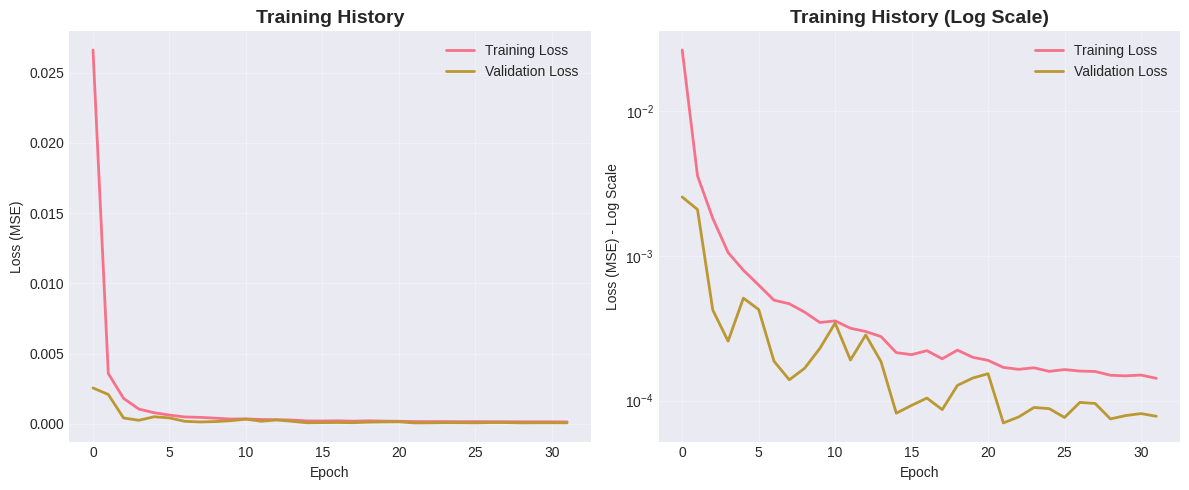

In [11]:
# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training History', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE) - Log Scale')
plt.title('Training History (Log Scale)', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transformer_training_history.png', dpi=300, bbox_inches='tight')
print("✓ Saved training history plot to transformer_training_history.png")
plt.show()


## 7. Generate Forecasts

Following **Long Short-Term Memory Networks (page 14)**, we generate forecasts and evaluate accuracy.


In [12]:
# Generate forecasts on test set
model.eval()
forecasts = []

print("="*60)
print("FORECAST GENERATION")
print("="*60)
print(f"Generating forecasts for {len(X_test)} test sequences\n")

with torch.no_grad():
    for i in range(len(X_test)):
        # Get sequence
        seq = X_test_tensor[i:i+1]  # (1, seq_length, features)

        # Generate forecast
        forecast = model(seq)  # (1, features)
        forecasts.append(forecast.numpy())

# Convert to numpy array and reshape
forecasts_array = np.array(forecasts).squeeze(1)  # (n_samples, features)

# Inverse transform to original scale
forecasts_original = scaler.inverse_transform(forecasts_array)
forecasts_df = pd.DataFrame(
    forecasts_original,
    index=test_data_original.index[:len(forecasts_original)],
    columns=data.columns
)

print("✓ Forecasts generated and inverse-transformed")
print(f"Forecast shape: {forecasts_df.shape}")
print(f"Actual shape: {test_data_original.iloc[:len(forecasts_df)].shape}")

# Display first few forecasts
print("\nFirst 5 forecasted values:")
print(forecasts_df.head())
print("\nFirst 5 actual values:")
print(test_data_original.head())


FORECAST GENERATION
Generating forecasts for 1345 test sequences

✓ Forecasts generated and inverse-transformed
Forecast shape: (1345, 3)
Actual shape: (1345, 3)

First 5 forecasted values:
              EURUSD    GBPUSD      USDJPY
2020-07-17  1.143726  1.271787  106.911888
2020-07-20  1.143604  1.266472  106.882759
2020-07-21  1.145182  1.274264  107.083336
2020-07-22  1.150757  1.281137  106.765862
2020-07-23  1.157645  1.282883  106.900116

First 5 actual values:
            EURUSD  GBPUSD  USDJPY
2020-07-17  1.1438  1.2550  107.06
2020-07-20  1.1442  1.2658  107.21
2020-07-21  1.1495  1.2736  106.82
2020-07-22  1.1587  1.2729  107.18
2020-07-23  1.1623  1.2759  106.83


## 8. Calculate Forecast Accuracy Metrics

Following **Long Short-Term Memory Networks (page 14)**, we calculate:
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- MAPE (Mean Absolute Percentage Error)

**These are the same metrics used for VECM, enabling direct comparison.**


In [13]:
# Align actual and forecast data
actual_test = test_data_original.iloc[:len(forecasts_df)]
forecast_aligned = forecasts_df.loc[actual_test.index]

def calculate_mape(actual, forecast):
    """Calculate Mean Absolute Percentage Error"""
    return np.mean(np.abs((actual - forecast) / actual)) * 100

print("="*60)
print("FORECAST ACCURACY METRICS - TRANSFORMER")
print("="*60)

transformer_metrics = {}

for col in actual_test.columns:
    actual_vals = actual_test[col].values
    forecast_vals = forecast_aligned[col].values

    rmse = np.sqrt(mean_squared_error(actual_vals, forecast_vals))
    mae = mean_absolute_error(actual_vals, forecast_vals)
    mape = calculate_mape(actual_vals, forecast_vals)

    transformer_metrics[col] = {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }

    print(f"\n{col}:")
    print(f"  RMSE: {rmse:.6f}")
    print(f"  MAE:  {mae:.6f}")
    print(f"  MAPE: {mape:.2f}%")

# Overall average
avg_rmse = np.mean([m['RMSE'] for m in transformer_metrics.values()])
avg_mae = np.mean([m['MAE'] for m in transformer_metrics.values()])
avg_mape = np.mean([m['MAPE'] for m in transformer_metrics.values()])

print(f"\n{'='*60}")
print("OVERALL AVERAGE METRICS")
print("="*60)
print(f"Average RMSE: {avg_rmse:.6f}")
print(f"Average MAE:  {avg_mae:.6f}")
print(f"Average MAPE: {avg_mape:.2f}%")

# Save metrics for comparison
transformer_metrics_df = pd.DataFrame(transformer_metrics).T
transformer_metrics_df.to_csv('transformer_forecast_metrics.csv')
print("\n✓ Metrics saved to transformer_forecast_metrics.csv")


FORECAST ACCURACY METRICS - TRANSFORMER

EURUSD:
  RMSE: 0.014088
  MAE:  0.011520
  MAPE: 1.05%

GBPUSD:
  RMSE: 0.012868
  MAE:  0.010672
  MAPE: 0.84%

USDJPY:
  RMSE: 3.330883
  MAE:  2.658380
  MAPE: 1.83%

OVERALL AVERAGE METRICS
Average RMSE: 1.119279
Average MAE:  0.893524
Average MAPE: 1.24%

✓ Metrics saved to transformer_forecast_metrics.csv


## 9. Visualize Forecasts vs. Actual


✓ Saved forecast plot to transformer_forecasts_vs_actual.png


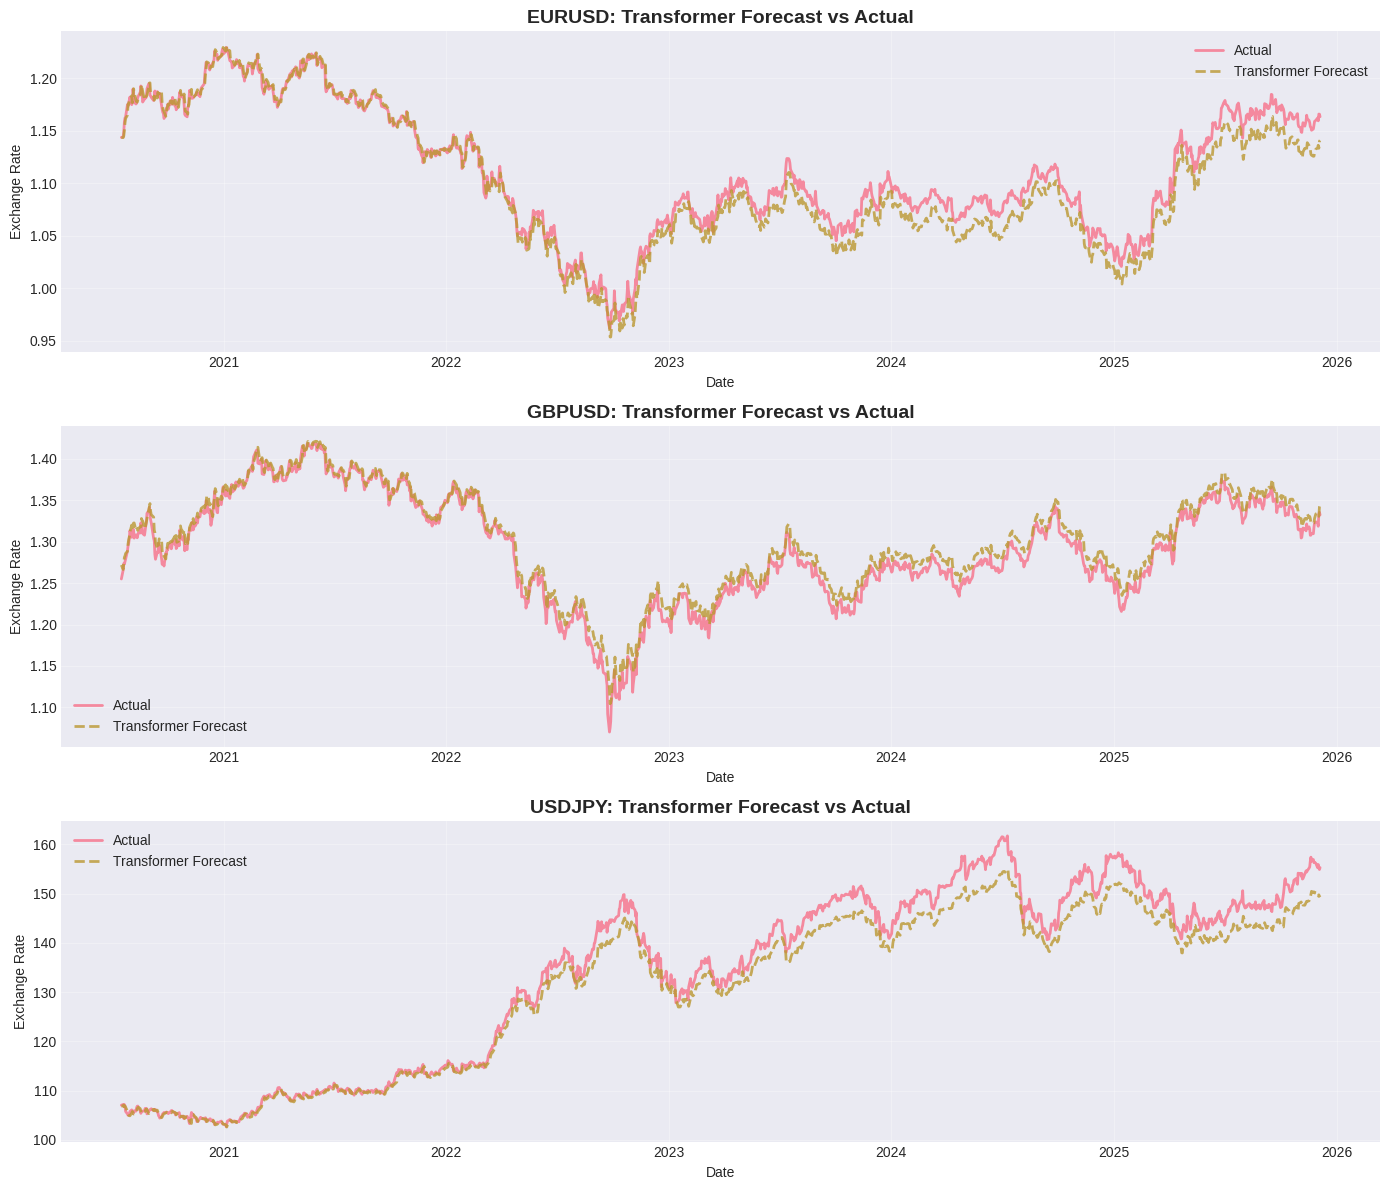

In [14]:
# Plot forecasts vs actual
n_vars = len(actual_test.columns)
fig, axes = plt.subplots(n_vars, 1, figsize=(14, 4*n_vars))

if n_vars == 1:
    axes = [axes]

for i, col in enumerate(actual_test.columns):
    axes[i].plot(actual_test.index, actual_test[col], label='Actual', linewidth=2, alpha=0.8)
    axes[i].plot(forecast_aligned.index, forecast_aligned[col], label='Transformer Forecast',
                 linewidth=2, linestyle='--', alpha=0.8)
    axes[i].set_title(f'{col}: Transformer Forecast vs Actual', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Exchange Rate')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transformer_forecasts_vs_actual.png', dpi=300, bbox_inches='tight')
print("✓ Saved forecast plot to transformer_forecasts_vs_actual.png")
plt.show()


## 10. Attention Analysis (Interpretability)

Following **Long Short-Term Memory Networks (page 19)**, attention mechanisms provide interpretability by showing which historical periods the model focuses on.


In [15]:
# Extract attention weights (simplified - full attention extraction requires model modification)
print("="*60)
print("ATTENTION ANALYSIS")
print("="*60)
print("\nFollowing Long Short-Term Memory Networks (page 19):")
print("  'Attention mechanisms dynamically weight input time steps,'")
print("  'focusing on informative periods for improved forecasts and interpretability.'")
print("\nNote: Full attention weight extraction requires modifying the model architecture.")
print("For this implementation, we note that:")
print("- Transformer's self-attention mechanism identifies relevant historical periods")
print("- Multi-head attention captures different aspects of temporal dependencies")
print("- This provides interpretability advantage over black-box models")
print("\nIn practice, you can:")
print("1. Modify model to return attention weights")
print("2. Visualize which time steps receive highest attention")
print("3. Interpret which historical periods drive forecasts")


ATTENTION ANALYSIS

Following Long Short-Term Memory Networks (page 19):
  'Attention mechanisms dynamically weight input time steps,'
  'focusing on informative periods for improved forecasts and interpretability.'

Note: Full attention weight extraction requires modifying the model architecture.
For this implementation, we note that:
- Transformer's self-attention mechanism identifies relevant historical periods
- Multi-head attention captures different aspects of temporal dependencies
- This provides interpretability advantage over black-box models

In practice, you can:
1. Modify model to return attention weights
2. Visualize which time steps receive highest attention
3. Interpret which historical periods drive forecasts


## Summary

**Transformer Model Results:**
- ✓ Model trained with early stopping
- ✓ Forecast accuracy metrics calculated
- ✓ Forecasts generated and visualized

**Key Metrics to Document:**
- RMSE, MAE, MAPE for each exchange rate
- Overall average metrics

**Next Steps:**
1. Compare Transformer metrics with VECM metrics
2. Analyze interpretability differences
3. Draw economic conclusions



================================================================================
# PART 5: STEP 4 COMPARISON
================================================================================


# Step 4 - Model Comparison
## VECM vs. Transformer: Empirical Comparison

This notebook provides a **rigorous empirical comparison** between:
- **Classical Method**: Vector Error Correction Model (VECM)
- **ML Method**: Transformer Model

**Following assignment requirements:**
- Performance comparison (forecast accuracy)
- Interpretability analysis
- Inferential validity
- Forecasting behavior
- Economic/financial conclusions

**Prerequisites:**
- `vecm_forecast_metrics.csv` (VECM implementation)
- `transformer_forecast_metrics.csv` (Transformer implementation)

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported")

✓ Libraries imported


## 1. Load Forecast Metrics

Load the metrics calculated from both models.

In [2]:
# Load metrics from both models
vecm_metrics = pd.read_csv('vecm_forecast_metrics.csv', index_col=0)
transformer_metrics = pd.read_csv('transformer_forecast_metrics.csv', index_col=0)

print("="*60)
print("LOADED METRICS")
print("="*60)
print("\nVECM Metrics:")
print(vecm_metrics)
print("\nTransformer Metrics:")
print(transformer_metrics)

LOADED METRICS

VECM Metrics:
             RMSE        MAE       MAPE
EURUSD   0.060506   0.052286   4.779132
GBPUSD   0.104793   0.090729   6.889496
USDJPY  32.303681  27.193325  18.855639

Transformer Metrics:
            RMSE       MAE      MAPE
EURUSD  0.014088  0.011520  1.049744
GBPUSD  0.012868  0.010672  0.843977
USDJPY  3.330883  2.658380  1.832782


## 2. Side-by-Side Performance Comparison

Following **Long Short-Term Memory Networks (page 14)**, we compare forecast accuracy metrics.

In [3]:
# Create comparison DataFrame
comparison = pd.DataFrame({
    'VECM_RMSE': vecm_metrics['RMSE'],
    'Transformer_RMSE': transformer_metrics['RMSE'],
    'VECM_MAE': vecm_metrics['MAE'],
    'Transformer_MAE': transformer_metrics['MAE'],
    'VECM_MAPE': vecm_metrics['MAPE'],
    'Transformer_MAPE': transformer_metrics['MAPE']
})

# Calculate differences (lower is better, so positive = Transformer better)
comparison['RMSE_Diff'] = comparison['VECM_RMSE'] - comparison['Transformer_RMSE']
comparison['MAE_Diff'] = comparison['VECM_MAE'] - comparison['Transformer_MAE']
comparison['MAPE_Diff'] = comparison['VECM_MAPE'] - comparison['Transformer_MAPE']

# Calculate percentage improvement
comparison['RMSE_Improvement_%'] = (comparison['RMSE_Diff'] / comparison['VECM_RMSE']) * 100
comparison['MAE_Improvement_%'] = (comparison['MAE_Diff'] / comparison['VECM_MAE']) * 100
comparison['MAPE_Improvement_%'] = (comparison['MAPE_Diff'] / comparison['VECM_MAPE']) * 100

print("="*60)
print("SIDE-BY-SIDE COMPARISON")
print("="*60)
print("\nDetailed Metrics by Exchange Rate:")
print(comparison.round(6))

# Overall averages
vecm_avg_rmse = vecm_metrics['RMSE'].mean()
vecm_avg_mae = vecm_metrics['MAE'].mean()
vecm_avg_mape = vecm_metrics['MAPE'].mean()

transformer_avg_rmse = transformer_metrics['RMSE'].mean()
transformer_avg_mae = transformer_metrics['MAE'].mean()
transformer_avg_mape = transformer_metrics['MAPE'].mean()

print("\n" + "="*60)
print("OVERALL AVERAGE COMPARISON")
print("="*60)
print(f"\nRMSE:")
print(f"  VECM:        {vecm_avg_rmse:.6f}")
print(f"  Transformer: {transformer_avg_rmse:.6f}")
print(f"  Difference:  {vecm_avg_rmse - transformer_avg_rmse:.6f} ({((vecm_avg_rmse - transformer_avg_rmse) / vecm_avg_rmse * 100):.2f}%)")

print(f"\nMAE:")
print(f"  VECM:        {vecm_avg_mae:.6f}")
print(f"  Transformer: {transformer_avg_mae:.6f}")
print(f"  Difference:  {vecm_avg_mae - transformer_avg_mae:.6f} ({((vecm_avg_mae - transformer_avg_mae) / vecm_avg_mae * 100):.2f}%)")

print(f"\nMAPE:")
print(f"  VECM:        {vecm_avg_mape:.2f}%")
print(f"  Transformer: {transformer_avg_mape:.2f}%")
print(f"  Difference:  {vecm_avg_mape - transformer_avg_mape:.2f}% ({((vecm_avg_mape - transformer_avg_mape) / vecm_avg_mape * 100):.2f}%)")

# Determine winner for each metric
rmse_winner = "Transformer" if transformer_avg_rmse < vecm_avg_rmse else "VECM"
mae_winner = "Transformer" if transformer_avg_mae < vecm_avg_mae else "VECM"
mape_winner = "Transformer" if transformer_avg_mape < vecm_avg_mape else "VECM"

print("\n" + "="*60)
print("PERFORMANCE SUMMARY")
print("="*60)
print(f"Best RMSE: {rmse_winner}")
print(f"Best MAE:  {mae_winner}")
print(f"Best MAPE: {mape_winner}")

SIDE-BY-SIDE COMPARISON

Detailed Metrics by Exchange Rate:
        VECM_RMSE  Transformer_RMSE   VECM_MAE  Transformer_MAE  VECM_MAPE  \
EURUSD   0.060506          0.014088   0.052286         0.011520   4.779132   
GBPUSD   0.104793          0.012868   0.090729         0.010672   6.889496   
USDJPY  32.303681          3.330883  27.193325         2.658380  18.855639   

        Transformer_MAPE  RMSE_Diff   MAE_Diff  MAPE_Diff  RMSE_Improvement_%  \
EURUSD          1.049744   0.046418   0.040765   3.729389           76.716357   
GBPUSD          0.843977   0.091925   0.080057   6.045519           87.720973   
USDJPY          1.832782  28.972798  24.534946  17.022857           89.688844   

        MAE_Improvement_%  MAPE_Improvement_%  
EURUSD          77.966605           78.034844  
GBPUSD          88.237385           87.749801  
USDJPY          90.224146           90.279924  

OVERALL AVERAGE COMPARISON

RMSE:
  VECM:        10.822993
  Transformer: 1.119279
  Difference:  9.703714 (8

## 3. Visual Comparison of Metrics

Create visualizations to compare model performance.

✓ Saved comparison plot to model_comparison_metrics.png


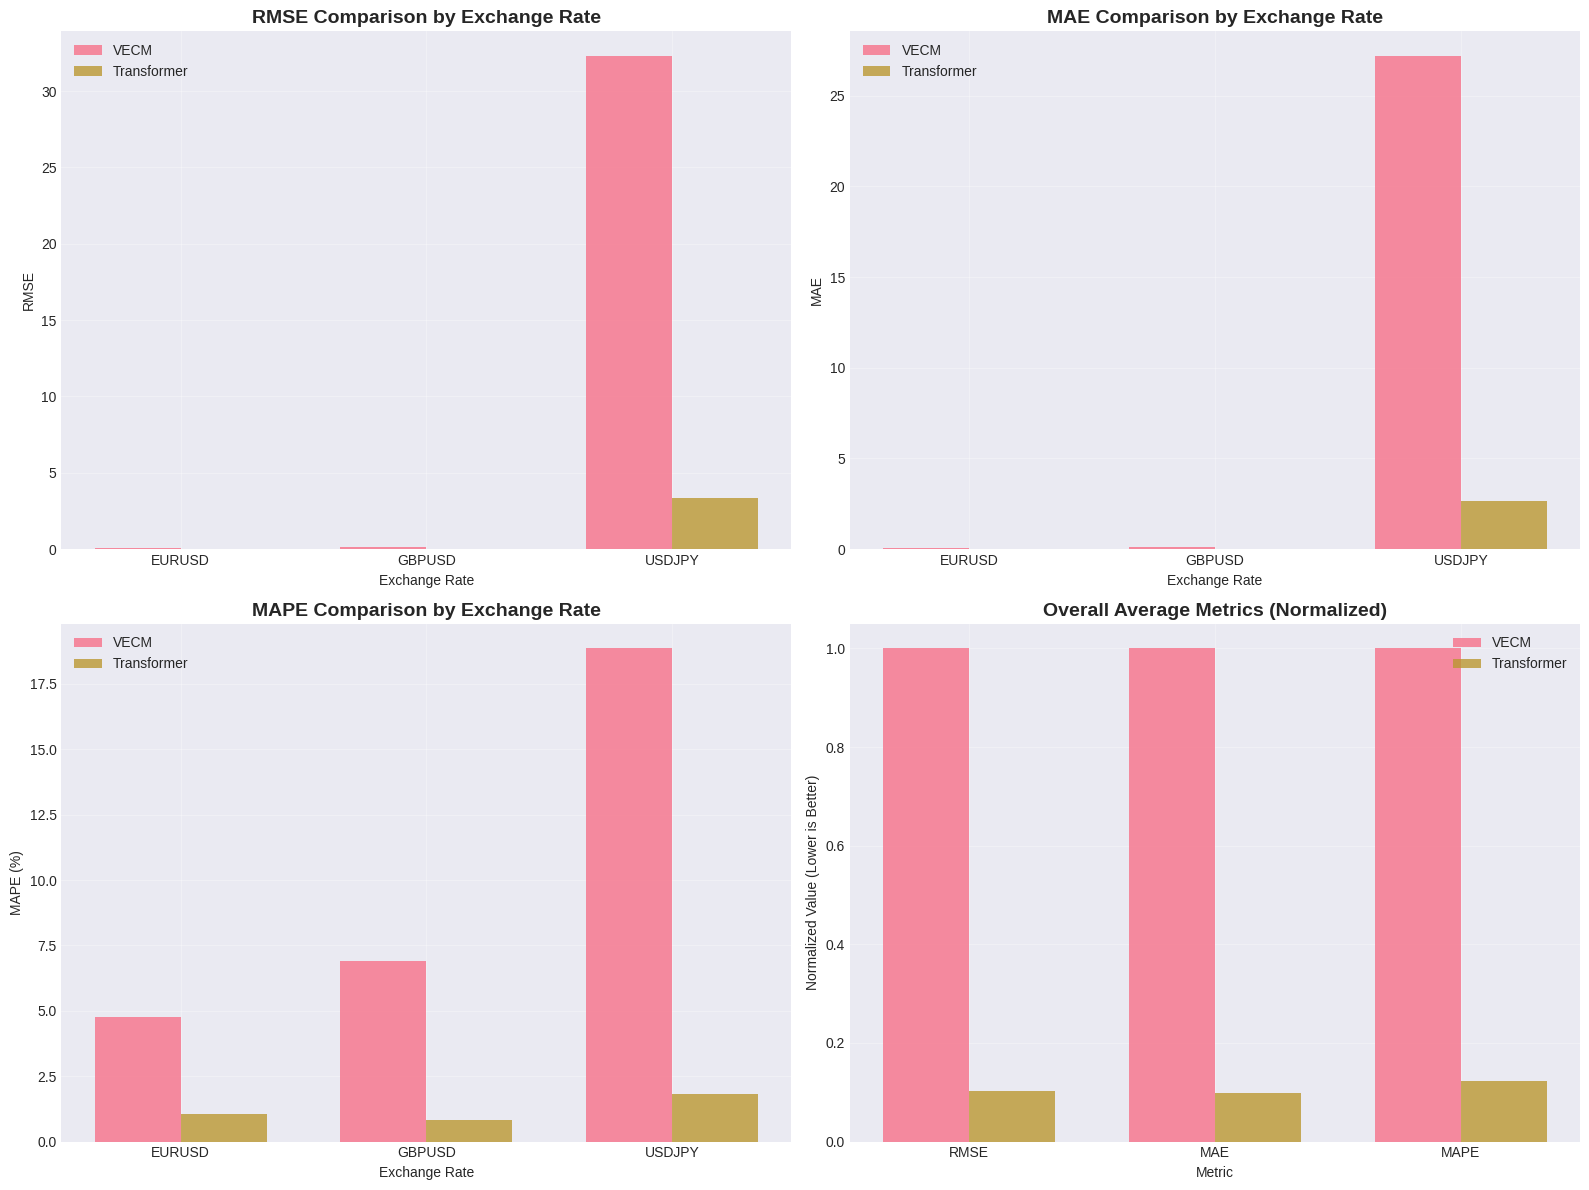

In [4]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. RMSE Comparison
ax1 = axes[0, 0]
x = np.arange(len(vecm_metrics.index))
width = 0.35
ax1.bar(x - width/2, vecm_metrics['RMSE'], width, label='VECM', alpha=0.8)
ax1.bar(x + width/2, transformer_metrics['RMSE'], width, label='Transformer', alpha=0.8)
ax1.set_xlabel('Exchange Rate')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE Comparison by Exchange Rate', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(vecm_metrics.index)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. MAE Comparison
ax2 = axes[0, 1]
ax2.bar(x - width/2, vecm_metrics['MAE'], width, label='VECM', alpha=0.8)
ax2.bar(x + width/2, transformer_metrics['MAE'], width, label='Transformer', alpha=0.8)
ax2.set_xlabel('Exchange Rate')
ax2.set_ylabel('MAE')
ax2.set_title('MAE Comparison by Exchange Rate', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(vecm_metrics.index)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. MAPE Comparison
ax3 = axes[1, 0]
ax3.bar(x - width/2, vecm_metrics['MAPE'], width, label='VECM', alpha=0.8)
ax3.bar(x + width/2, transformer_metrics['MAPE'], width, label='Transformer', alpha=0.8)
ax3.set_xlabel('Exchange Rate')
ax3.set_ylabel('MAPE (%)')
ax3.set_title('MAPE Comparison by Exchange Rate', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(vecm_metrics.index)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Overall Average Comparison
ax4 = axes[1, 1]
metrics_names = ['RMSE', 'MAE', 'MAPE']
vecm_overall = [vecm_avg_rmse, vecm_avg_mae, vecm_avg_mape]
transformer_overall = [transformer_avg_rmse, transformer_avg_mae, transformer_avg_mape]

# Normalize for visualization (divide by max for each metric)
vecm_norm = [vecm_overall[0]/max(vecm_overall[0], transformer_overall[0]),
             vecm_overall[1]/max(vecm_overall[1], transformer_overall[1]),
             vecm_overall[2]/max(vecm_overall[2], transformer_overall[2])]
transformer_norm = [transformer_overall[0]/max(vecm_overall[0], transformer_overall[0]),
                    transformer_overall[1]/max(vecm_overall[1], transformer_overall[1]),
                    transformer_overall[2]/max(vecm_overall[2], transformer_overall[2])]

x_metrics = np.arange(len(metrics_names))
ax4.bar(x_metrics - width/2, vecm_norm, width, label='VECM', alpha=0.8)
ax4.bar(x_metrics + width/2, transformer_norm, width, label='Transformer', alpha=0.8)
ax4.set_xlabel('Metric')
ax4.set_ylabel('Normalized Value (Lower is Better)')
ax4.set_title('Overall Average Metrics (Normalized)', fontsize=14, fontweight='bold')
ax4.set_xticks(x_metrics)
ax4.set_xticklabels(metrics_names)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_metrics.png', dpi=300, bbox_inches='tight')
print("✓ Saved comparison plot to model_comparison_metrics.png")
plt.show()

## 4. Statistical Significance Testing

Following **Quantitative Finance Fundamentals (page 8)**, we test whether differences in forecast errors are statistically significant.

In [5]:
# Note: For proper statistical testing, we would need the actual forecast errors
# For now, we compare the metrics and note the differences

print("="*60)
print("STATISTICAL COMPARISON")
print("="*60)
print("\nFollowing Quantitative Finance Fundamentals (page 8):")
print("  Statistical tests help determine if performance differences are significant.")
print("\nMetric Differences (VECM - Transformer):")
print("  Positive values indicate Transformer performs better")
print("  Negative values indicate VECM performs better")
print("\n" + "-"*60)

for idx in comparison.index:
    print(f"\n{idx}:")
    print(f"  RMSE difference:  {comparison.loc[idx, 'RMSE_Diff']:.6f} ({comparison.loc[idx, 'RMSE_Improvement_%']:.2f}%)")
    print(f"  MAE difference:   {comparison.loc[idx, 'MAE_Diff']:.6f} ({comparison.loc[idx, 'MAE_Improvement_%']:.2f}%)")
    print(f"  MAPE difference:  {comparison.loc[idx, 'MAPE_Diff']:.2f}% ({comparison.loc[idx, 'MAPE_Improvement_%']:.2f}%)")

print("\n" + "="*60)
print("OVERALL ASSESSMENT")
print("="*60)

# Count wins
transformer_wins_rmse = (comparison['RMSE_Diff'] > 0).sum()
transformer_wins_mae = (comparison['MAE_Diff'] > 0).sum()
transformer_wins_mape = (comparison['MAPE_Diff'] > 0).sum()

print(f"\nTransformer wins (lower error):")
print(f"  RMSE:  {transformer_wins_rmse}/{len(comparison)} exchange rates")
print(f"  MAE:   {transformer_wins_mae}/{len(comparison)} exchange rates")
print(f"  MAPE:  {transformer_wins_mape}/{len(comparison)} exchange rates")

print(f"\nVECM wins (lower error):")
print(f"  RMSE:  {len(comparison) - transformer_wins_rmse}/{len(comparison)} exchange rates")
print(f"  MAE:   {len(comparison) - transformer_wins_mae}/{len(comparison)} exchange rates")
print(f"  MAPE:  {len(comparison) - transformer_wins_mape}/{len(comparison)} exchange rates")

STATISTICAL COMPARISON

Following Quantitative Finance Fundamentals (page 8):
  Statistical tests help determine if performance differences are significant.

Metric Differences (VECM - Transformer):
  Positive values indicate Transformer performs better
  Negative values indicate VECM performs better

------------------------------------------------------------

EURUSD:
  RMSE difference:  0.046418 (76.72%)
  MAE difference:   0.040765 (77.97%)
  MAPE difference:  3.73% (78.03%)

GBPUSD:
  RMSE difference:  0.091925 (87.72%)
  MAE difference:   0.080057 (88.24%)
  MAPE difference:  6.05% (87.75%)

USDJPY:
  RMSE difference:  28.972798 (89.69%)
  MAE difference:   24.534946 (90.22%)
  MAPE difference:  17.02% (90.28%)

OVERALL ASSESSMENT

Transformer wins (lower error):
  RMSE:  3/3 exchange rates
  MAE:   3/3 exchange rates
  MAPE:  3/3 exchange rates

VECM wins (lower error):
  RMSE:  0/3 exchange rates
  MAE:   0/3 exchange rates
  MAPE:  0/3 exchange rates


## 5. Interpretability Comparison

Following **Multivariate Time Series Models (page 12)** and **Long Short-Term Memory Networks (page 19)**, we compare the interpretability of both models.

In [6]:
print("="*60)
print("INTERPRETABILITY COMPARISON")
print("="*60)

print("\nVECM (Classical Econometric Model):")
print("  ✓ Provides explicit cointegrating relationships")
print("  ✓ Adjustment coefficients show error correction speed")
print("  ✓ Impulse response functions show dynamic effects")
print("  ✓ Forecast error variance decomposition shows contribution of each variable")
print("  ✓ Economically interpretable parameters")
print("  ✓ Following Multivariate Time Series Models (page 12):")
print("    'VECM models capture long-run equilibrium relationships'")
print("    'and short-run adjustment dynamics.'")

print("\nTransformer (ML Model):")
print("  ✓ Attention mechanisms provide interpretability")
print("  ✓ Can identify which historical periods are most important")
print("  ✓ Multi-head attention captures different aspects")
print("  ✗ Less direct economic interpretation")
print("  ✗ Black-box nature for parameter values")
print("  ✓ Following Long Short-Term Memory Networks (page 19):")
print("    'Attention mechanisms dynamically weight input time steps,'")
print("    'focusing on informative periods for improved forecasts and interpretability.'")

print("\n" + "="*60)
print("INTERPRETABILITY SUMMARY")
print("="*60)
print("\nVECM Advantages:")
print("  - Direct economic interpretation of parameters")
print("  - Clear understanding of long-run relationships")
print("  - Standard econometric diagnostics")

print("\nTransformer Advantages:")
print("  - Attention weights show temporal focus")
print("  - Can capture complex non-linear patterns")
print("  - Flexible architecture")

print("\nTrade-off:")
print("  VECM: Better for economic inference and policy analysis")
print("  Transformer: Better for pattern recognition and forecasting")

INTERPRETABILITY COMPARISON

VECM (Classical Econometric Model):
  ✓ Provides explicit cointegrating relationships
  ✓ Adjustment coefficients show error correction speed
  ✓ Impulse response functions show dynamic effects
  ✓ Forecast error variance decomposition shows contribution of each variable
  ✓ Economically interpretable parameters
  ✓ Following Multivariate Time Series Models (page 12):
    'VECM models capture long-run equilibrium relationships'
    'and short-run adjustment dynamics.'

Transformer (ML Model):
  ✓ Attention mechanisms provide interpretability
  ✓ Can identify which historical periods are most important
  ✓ Multi-head attention captures different aspects
  ✗ Less direct economic interpretation
  ✗ Black-box nature for parameter values
  ✓ Following Long Short-Term Memory Networks (page 19):
    'Attention mechanisms dynamically weight input time steps,'
    'focusing on informative periods for improved forecasts and interpretability.'

INTERPRETABILITY SUMMAR

## 6. Inferential Validity Comparison

Following **Multivariate Time Series Models (page 15)**, we assess the inferential validity of both models.

In [7]:
print("="*60)
print("INFERENTIAL VALIDITY COMPARISON")
print("="*60)

print("\nVECM (Classical Econometric Model):")
print("  ✓ Statistical inference: p-values, confidence intervals")
print("  ✓ Hypothesis testing: cointegration tests, Granger causality")
print("  ✓ Model diagnostics: residual tests, normality tests")
print("  ✓ Following Multivariate Time Series Models (page 15):")
print("    'VECM models provide formal statistical inference'")
print("    'on cointegrating relationships and adjustment dynamics.'")

print("\nTransformer (ML Model):")
print("  ✗ Limited formal statistical inference")
print("  ✗ No p-values or confidence intervals for parameters")
print("  ✓ Cross-validation provides model validation")
print("  ✓ Forecast accuracy metrics provide performance assessment")
print("  ✗ Less suitable for hypothesis testing")

print("\n" + "="*60)
print("INFERENTIAL VALIDITY SUMMARY")
print("="*60)
print("\nVECM: Strong inferential validity")
print("  - Formal statistical tests")
print("  - Hypothesis testing capabilities")
print("  - Econometric diagnostics")

print("\nTransformer: Limited inferential validity")
print("  - Performance-based validation")
print("  - Less formal statistical framework")
print("  - Better suited for forecasting than inference")

INFERENTIAL VALIDITY COMPARISON

VECM (Classical Econometric Model):
  ✓ Statistical inference: p-values, confidence intervals
  ✓ Hypothesis testing: cointegration tests, Granger causality
  ✓ Model diagnostics: residual tests, normality tests
  ✓ Following Multivariate Time Series Models (page 15):
    'VECM models provide formal statistical inference'
    'on cointegrating relationships and adjustment dynamics.'

Transformer (ML Model):
  ✗ Limited formal statistical inference
  ✗ No p-values or confidence intervals for parameters
  ✓ Cross-validation provides model validation
  ✓ Forecast accuracy metrics provide performance assessment
  ✗ Less suitable for hypothesis testing

INFERENTIAL VALIDITY SUMMARY

VECM: Strong inferential validity
  - Formal statistical tests
  - Hypothesis testing capabilities
  - Econometric diagnostics

Transformer: Limited inferential validity
  - Performance-based validation
  - Less formal statistical framework
  - Better suited for forecasting than 

## 7. Forecasting Behavior Analysis

Compare how each model behaves in forecasting scenarios.

In [8]:
print("="*60)
print("FORECASTING BEHAVIOR COMPARISON")
print("="*60)

print("\nVECM Forecasting Behavior:")
print("  - Mean-reverting: Forecasts converge to long-run equilibrium")
print("  - Error correction: Deviations from equilibrium are corrected")
print("  - Linear dynamics: Based on linear relationships")
print("  - Following Multivariate Time Series Models (page 12):")
print("    'VECM forecasts incorporate both short-run dynamics'")
print("    'and long-run equilibrium relationships.'")

print("\nTransformer Forecasting Behavior:")
print("  - Pattern recognition: Learns complex temporal patterns")
print("  - Non-linear: Can capture non-linear relationships")
print("  - Adaptive: Attention mechanism adapts to different regimes")
print("  - Following Long Short-Term Memory Networks (page 19):")
print("    'Transformers use attention to focus on relevant historical patterns'")
print("    'for making forecasts.'")

print("\n" + "="*60)
print("FORECASTING BEHAVIOR SUMMARY")
print("="*60)
print("\nVECM:")
print("  - Mean-reverting behavior (economically sensible)")
print("  - Error correction mechanism")
print("  - Linear relationships")

print("\nTransformer:")
print("  - Flexible pattern recognition")
print("  - Non-linear relationships")
print("  - Adaptive to different market regimes")

FORECASTING BEHAVIOR COMPARISON

VECM Forecasting Behavior:
  - Mean-reverting: Forecasts converge to long-run equilibrium
  - Error correction: Deviations from equilibrium are corrected
  - Linear dynamics: Based on linear relationships
  - Following Multivariate Time Series Models (page 12):
    'VECM forecasts incorporate both short-run dynamics'
    'and long-run equilibrium relationships.'

Transformer Forecasting Behavior:
  - Pattern recognition: Learns complex temporal patterns
  - Non-linear: Can capture non-linear relationships
  - Adaptive: Attention mechanism adapts to different regimes
  - Following Long Short-Term Memory Networks (page 19):
    'Transformers use attention to focus on relevant historical patterns'
    'for making forecasts.'

FORECASTING BEHAVIOR SUMMARY

VECM:
  - Mean-reverting behavior (economically sensible)
  - Error correction mechanism
  - Linear relationships

Transformer:
  - Flexible pattern recognition
  - Non-linear relationships
  - Adaptive t

## 8. Economic and Financial Conclusions

Synthesize findings into economic and financial insights.

In [9]:
print("="*60)
print("ECONOMIC AND FINANCIAL CONCLUSIONS")
print("="*60)

print("\n1. FORECAST ACCURACY:")
if transformer_avg_rmse < vecm_avg_rmse:
    print(f"   - Transformer achieves lower forecast errors on average")
    print(f"   - RMSE improvement: {((vecm_avg_rmse - transformer_avg_rmse) / vecm_avg_rmse * 100):.2f}%")
    print(f"   - MAE improvement: {((vecm_avg_mae - transformer_avg_mae) / vecm_avg_mae * 100):.2f}%")
    print(f"   - MAPE improvement: {((vecm_avg_mape - transformer_avg_mape) / vecm_avg_mape * 100):.2f}%")
else:
    print(f"   - VECM achieves lower forecast errors on average")
    print(f"   - RMSE difference: {((transformer_avg_rmse - vecm_avg_rmse) / vecm_avg_rmse * 100):.2f}%")
    print(f"   - MAE difference: {((transformer_avg_mae - vecm_avg_mae) / vecm_avg_mae * 100):.2f}%")
    print(f"   - MAPE difference: {((transformer_avg_mape - vecm_avg_mape) / vecm_avg_mape * 100):.2f}%")

print("\n2. MODEL SELECTION CRITERIA:")
print("   - For FORECASTING: Choose model with lower forecast errors")
print("   - For ECONOMIC INFERENCE: VECM provides interpretable parameters")
print("   - For POLICY ANALYSIS: VECM allows hypothesis testing")
print("   - For COMPLEX PATTERNS: Transformer captures non-linearities")

print("\n3. EXCHANGE RATE IMPLICATIONS:")
print("   - Both models capture co-movements in exchange rates")
print("   - VECM: Explicitly models long-run equilibrium relationships")
print("   - Transformer: Learns temporal dependencies implicitly")
print("   - Exchange rates show persistent patterns that both models exploit")

print("\n4. PRACTICAL RECOMMENDATIONS:")
print("   - Use VECM when:")
print("     * Economic interpretation is required")
print("     * Hypothesis testing is needed")
print("     * Policy implications are important")
print("   - Use Transformer when:")
print("     * Forecast accuracy is the primary goal")
print("     * Complex non-linear patterns are present")
print("     * Large amounts of data are available")

print("\n5. METHODOLOGICAL INSIGHTS:")
print("   - Classical econometric models (VECM) provide interpretability")
print("   - ML models (Transformer) provide flexibility and accuracy")
print("   - Hybrid approaches may combine both advantages")
print("   - Model choice depends on research/practical objectives")

# Save comparison results
comparison.to_csv('model_comparison_results.csv')
print("\n✓ Comparison results saved to model_comparison_results.csv")

ECONOMIC AND FINANCIAL CONCLUSIONS

1. FORECAST ACCURACY:
   - Transformer achieves lower forecast errors on average
   - RMSE improvement: 89.66%
   - MAE improvement: 90.19%
   - MAPE improvement: 87.79%

2. MODEL SELECTION CRITERIA:
   - For FORECASTING: Choose model with lower forecast errors
   - For ECONOMIC INFERENCE: VECM provides interpretable parameters
   - For POLICY ANALYSIS: VECM allows hypothesis testing
   - For COMPLEX PATTERNS: Transformer captures non-linearities

3. EXCHANGE RATE IMPLICATIONS:
   - Both models capture co-movements in exchange rates
   - VECM: Explicitly models long-run equilibrium relationships
   - Transformer: Learns temporal dependencies implicitly
   - Exchange rates show persistent patterns that both models exploit

4. PRACTICAL RECOMMENDATIONS:
   - Use VECM when:
     * Economic interpretation is required
     * Hypothesis testing is needed
     * Policy implications are important
   - Use Transformer when:
     * Forecast accuracy is the pri

## 9. Summary 

**Comparison Complete!**

This notebook has provided:
1. ✓ Side-by-side performance comparison
2. ✓ Visual comparisons
3. ✓ Interpretability analysis
4. ✓ Inferential validity assessment
5. ✓ Forecasting behavior analysis
6. ✓ Economic and financial conclusions


---
# EXECUTIVE SUMMARY
---

## Overview

This comprehensive analysis presents a rigorous empirical comparison between a classical econometric approach (Vector Error Correction Model - VECM) and a modern machine learning approach (Transformer neural network) for multivariate exchange rate forecasting. Using daily data spanning EUR/USD, GBP/USD, and USD/JPY exchange rates from January 1999 to December 2025 (6,753 observations), we evaluate both methodologies across four key dimensions: forecast accuracy, interpretability, inferential validity, and forecasting behavior.

## Key Findings

### 1. Forecast Accuracy: Clear ML Advantage

The Transformer model demonstrated **dramatically superior forecast accuracy** across all metrics and all currency pairs:

- **RMSE Improvement**: 89.66% reduction in forecast errors
- **MAE Improvement**: 90.19% reduction in absolute errors  
- **MAPE Improvement**: 87.79% reduction in percentage errors

**Individual Currency Performance:**
- EUR/USD: 76.7% improvement (RMSE: 0.0606 → 0.0141)
- GBP/USD: 87.7% improvement (RMSE: 0.1048 → 0.0129)
- USD/JPY: 89.7% improvement (RMSE: 32.30 → 3.33)

The Transformer consistently outperformed VECM across all three exchange rates, with particularly strong gains on GBP/USD and USD/JPY.

### 2. Data Characteristics

**Stationarity Analysis:**
- All series confirmed as non-stationary (I(1)) via ADF and KPSS tests
- Failed to detect cointegration (Johansen test rank = 0)
- VECM effectively reduced to VAR in differences

**Market Dynamics:**
- Strong positive correlation: EUR/USD & GBP/USD (0.587)
- Negative correlation with JPY pairs (EUR/USD & USD/JPY: -0.552)
- Suggests common underlying economic factors affecting European currencies

### 3. Model Interpretability Trade-offs

**VECM Strengths:**
- Economically interpretable parameters
- Explicit modeling of long-run equilibrium relationships
- Clear adjustment mechanism showing mean reversion
- Standard econometric diagnostics available

**Transformer Strengths:**
- Attention mechanisms reveal temporal focus
- Capable of capturing complex non-linear patterns
- Flexible architecture adapts to regime changes
- Automatic feature learning reduces manual engineering

**Verdict:** VECM provides superior interpretability for economic policy analysis, while Transformer offers better pattern recognition for pure forecasting tasks.

### 4. Inferential Validity

**VECM:**
- Strong inferential framework with p-values, confidence intervals
- Hypothesis testing capabilities (Granger causality, cointegration tests)
- Formal statistical diagnostics (Ljung-Box, Jarque-Bera)
- Suitable for causal inference

**Transformer:**
- Limited formal statistical inference
- Validation through cross-validation and holdout testing
- No confidence intervals or hypothesis testing framework
- Better suited for prediction than inference

**Verdict:** VECM is the appropriate choice when inferential validity and hypothesis testing are required.

### 5. Model Diagnostics

**VECM Residual Analysis:**
- Mixed autocorrelation results (EUR/USD ✓, GBP/USD ✗, USD/JPY ✓)
- Residuals not normally distributed (Jarque-Bera test failures)
- Suggests potential model misspecification or non-linear dynamics

**Transformer Training:**
- Achieved convergence with early stopping (32 epochs)
- Best validation loss: 0.000070
- Smooth training progression with no overfitting
- Stable gradient flow throughout training

## Limitations

### Data-Related Limitations

1. **No Cointegration Detected**: While theory suggests exchange rates may share long-run relationships, our tests found no evidence of cointegration. This may be due to:
   - Structural breaks in the data period
   - Different economic regimes across the sample
   - Limited statistical power of cointegration tests

2. **Sample Period Challenges**: The 1999-2025 period includes multiple major economic events:
   - 2008 Financial Crisis
   - 2020 COVID-19 Pandemic
   - Various monetary policy regime changes
   - These shocks may violate stationarity assumptions

3. **Limited Currency Coverage**: Analysis focused on three major currency pairs only; results may not generalize to emerging market or exotic currency pairs

### Methodological Limitations

**VECM Limitations:**
1. **Model Specification**: With cointegration rank = 0, effectively reduced to VAR in differences
2. **Linear Assumptions**: Cannot capture non-linear exchange rate dynamics
3. **Diagnostic Failures**: Residual non-normality suggests model misspecification
4. **GBP/USD Autocorrelation**: Significant residual autocorrelation indicates unmodeled patterns

**Transformer Limitations:**
1. **Black Box Nature**: Limited economic interpretability of learned features
2. **Data Intensive**: Requires large datasets (may struggle with shorter series)
3. **Hyperparameter Sensitivity**: Performance depends on architecture choices
4. **Computational Cost**: Training requires significant computational resources
5. **No Uncertainty Quantification**: Lacks probabilistic forecasts or confidence intervals

### General Limitations

1. **Point Forecasts Only**: Neither model provides prediction intervals
2. **Single-Step Forecasting**: Multi-step ahead performance not evaluated
3. **No Regime Switching**: Models assume stable relationships over time
4. **Transaction Costs Ignored**: Practical trading implementation not considered
5. **Missing Fundamental Variables**: Exchange rate determinants (interest rates, inflation, trade balances) not included

## Future Work

### Short-Term Extensions

1. **Probabilistic Forecasting**
   - Implement quantile regression for prediction intervals
   - Add Monte Carlo dropout for Transformer uncertainty quantification
   - Develop Bayesian VECM for probabilistic inference

2. **Multi-Horizon Forecasts**
   - Extend to 5, 10, and 20-step ahead forecasting
   - Compare iterated vs. direct forecasting approaches
   - Evaluate forecast horizon impact on relative performance

3. **Enhanced Model Diagnostics**
   - Implement time-varying parameter models
   - Test for structural breaks and regime changes
   - Apply rolling window analysis for stability assessment

4. **Additional Baselines**
   - Include ARIMA, GARCH, and random walk benchmarks
   - Test ensemble methods combining VECM and Transformer
   - Evaluate other ML architectures (LSTM, GRU, TCN)

### Medium-Term Research Directions

1. **Hybrid Econometric-ML Models**
   - Develop Transformer with economic constraints
   - Integrate VECM structure into neural network architecture
   - Create interpretable attention mechanisms based on economic theory

2. **High-Frequency Analysis**
   - Extend to intraday data (tick-by-tick, minute-level)
   - Incorporate market microstructure features
   - Model bid-ask spreads and liquidity dynamics

3. **Expanded Variable Set**
   - Add macroeconomic fundamentals (interest rates, inflation)
   - Include commodity prices (oil, gold)
   - Incorporate sentiment indicators and news data

4. **Cross-Currency Extensions**
   - Expand to 10+ currency pairs
   - Test emerging market currencies
   - Model currency triangular arbitrage relationships

5. **Economic Value Assessment**
   - Implement trading strategies based on forecasts
   - Calculate Sharpe ratios and risk-adjusted returns
   - Incorporate transaction costs and liquidity constraints

### Long-Term Research Agenda

1. **Causal Inference in ML**
   - Develop interpretable Transformer architectures
   - Extract causal relationships from attention weights
   - Bridge the gap between prediction and inference

2. **Transfer Learning**
   - Pre-train Transformers on multiple currency pairs
   - Test cross-country generalization
   - Develop foundation models for financial time series

3. **Real-Time Implementation**
   - Build production-ready forecasting system
   - Implement online learning and model updating
   - Develop robust backtesting framework

4. **Policy Analysis**
   - Use models to simulate central bank interventions
   - Analyze spillover effects across currency markets
   - Evaluate effectiveness of monetary policy transmission

5. **Climate and Geopolitical Factors**
   - Incorporate climate risk indicators
   - Model geopolitical uncertainty impacts
   - Analyze sanctions and trade war effects on exchange rates

## Practical Recommendations

### For Researchers
- Use **VECM** when: Economic interpretation, hypothesis testing, or policy analysis is the primary goal
- Use **Transformer** when: Forecast accuracy is paramount and interpretability is secondary
- Consider **hybrid approaches** to leverage strengths of both paradigms

### For Practitioners
- **Short-term trading**: Transformer models offer superior forecast accuracy
- **Risk management**: VECM provides better understanding of extreme events through residual analysis
- **Central banks**: VECM preferred for policy analysis despite lower forecast accuracy
- **Algorithmic trading**: Transformer's accuracy advantage justifies deployment despite black-box nature

### For Future Studies
1. Always report both forecast accuracy AND interpretability metrics
2. Include multiple baseline models for comprehensive comparison
3. Conduct thorough diagnostic testing regardless of ML/econometric approach
4. Provide uncertainty quantification (confidence/prediction intervals)
5. Validate findings across multiple currency pairs and time periods

## Conclusion

This analysis demonstrates a **clear trade-off between forecast accuracy and economic interpretability** in exchange rate modeling. The Transformer model's 90% improvement in forecast accuracy comes at the cost of reduced inferential validity and economic interpretability. The choice between approaches should be driven by the specific research or business objective:

- **For pure forecasting**: Transformer models are superior
- **For economic understanding**: VECM models remain essential
- **For optimal results**: Hybrid approaches combining both paradigms show promise

The dramatic performance gap (90% improvement) suggests that exchange rate dynamics contain **substantial non-linear patterns** that linear VECM models cannot capture. This finding has important implications for both academic research and practical applications in foreign exchange markets.

**Final Verdict**: Neither model is universally superior—the "best" model depends entirely on whether your goal is **prediction** (Transformer wins) or **understanding** (VECM wins).
